# **Aprendizaje Automático - Proyecto Final - Aprendizaje Perezoso de Reglas Bayesianas**

### **Autores: Alejandro Cárdenas Barranco, Mónica Calzado Granados, Jesús García León, Álvaro Rodríguez Gallardo, Juan Manuel Rodríguez Gómez**

# **1. Introducción**

## **1.1. Descripción del Problema**

En el campo del aprendizaje automático, el clasificador Naive Bayes es conocido por su simplicidad y efectividad en la clasificación, especialmente útil en situaciones donde se manejan grandes volúmenes de datos y muchos atributos. Este clasificador utiliza el teorema de Bayes y asume que los atributos son independientes entre sí, lo cual simplifica enormemente los cálculos al descomponer la probabilidad conjunta en un producto de probabilidades condicionales. Sin embargo, esta suposición de independencia muchas veces no se mantiene en escenarios reales, donde las interacciones entre atributos son comunes y significativas. Ignorar estas dependencias puede resultar en errores considerables en la predicción, limitando seriamente la utilidad del clasificador en muchas aplicaciones prácticas, como en medicina, seguridad informática y marketing digital.

Además, calcular las probabilidades para combinaciones específicas de atributos con un gran número de estos puede resultar en un costo computacional muy alto, especialmente porque el número de combinaciones posibles de atributos aumenta rápidamente a medida que se añaden más atributos. Este problema central representa una limitación crítica para el uso efectivo del clasificador Naive Bayes en la práctica.

Este proyecto investiga una solución innovadora a estas limitaciones mediante la implementación del **algoritmo de Reglas Bayesianas Perezosas (LBR)**. LBR es un enfoque avanzado que incorpora técnicas de aprendizaje perezoso en la inducción de árboles bayesianos, permitiendo la creación de reglas adaptadas específicamente a cada instancia de prueba. Este método no solo promete superar el problema de los "pequeños disjuntos", característico de los modelos de árboles bayesianos que subdividen el espacio de características en nodos con clasificadores Naive Bayes locales, sino que también ofrece una flexibilidad en el manejo de dependencias entre atributos con una suposición de independencia condicional menos estricta.

A través de la estrategia de LBR, se busca adaptar el clasificador a cada nueva instancia en la fase de clasificación, lo que podría resultar en una mejora significativa de la precisión en una amplia variedad de dominios naturales. El enfoque perezoso, que ajusta el modelo a las características específicas de cada instancia en el momento de la clasificación, representa una promesa considerable para mejorar tanto la precisión predictiva como la eficiencia computacional.

En resumen, este proyecto tiene como objetivo implementar y evaluar experimentalmente LBR, un algoritmo que integra el aprendizaje perezoso con técnicas de clasificación bayesiana, para abordar eficazmente las interdependencias entre atributos y mejorar el rendimiento del clasificador Naive Bayes en escenarios donde su suposición de independencia falla. Se espera que esta implementación demuestre una capacidad superior para manejar las complejidades del mundo real, validando así su utilidad práctica en diversas aplicaciones.

## **1.2. Objetivos del Proyecto**

A continuación, se detallan los objetivos claros y concretos que este proyecto pretende alcanzar:

- **Implementación del Algoritmo LBR:** Desarrollar una implementación completa del algoritmo de Reglas Bayesianas Perezosas (LBR) que sea coherente con las especificaciones del artículo [1], asegurando que se adhiera a las convenciones de programación de scikit-learn.

- **Validación de la Implementación:** Validar que la implementación del algoritmo funciona correctamente mediante pruebas unitarias y comprobaciones de integridad que confirmen su capacidad para generar clasificaciones precisas y manejar adecuadamente los datos de entrada.

- **Análisis Comparativo de Rendimiento:** Comparar el rendimiento del algoritmo LBR con otros clasificadores estándar, como Naive Bayes, árboles de decisión, y otros algoritmos de aprendizaje perezoso para demostrar sus ventajas en términos de precisión de clasificación y manejo de dependencias entre atributos.

- **Evaluación en Diferentes Conjuntos de Datos:** Evaluar el algoritmo en varios conjuntos de datos, preferentemente aquellos utilizados en las prácticas de la asignatura, para determinar su eficacia en diferentes escenarios y su capacidad para generalizar a partir de distintos tipos de datos.

## **1.3. Algoritmo de Reglas Bayesianas Perezosas (LBR)**

En el artículo [1] se revisan las técnicas existentes para mejorar el clasificador Naive Bayes y se motiva la implementación de un nuevo enfoque, denominado **Reglas Bayesianas Perezosas** (*Lazy Bayesian Rules*, LBR). Este enfoque busca superar las limitaciones del clasificador Naive Bayes, al utilizar una estrategia de aprendizaje perezoso que se adapta mejor a las interdependencias entre atributos.

El artículo [1] presenta LBR como una solución que combina los beneficios del aprendizaje perezoso con la teoría bayesiana, para formar reglas de decisión. Estas reglas se adaptan dinámicamente a cada instancia específica que queramos clasificar. La motivación para desarrollar LBR surge de la observación de que el clasificador Naive Bayes, aunque es teóricamente óptimo bajo ciertas condiciones, a veces no maneja bien la dependencia entre atributos, lo que puede llevar a una degradación del rendimiento en la práctica. LBR intenta superar este problema al generar reglas que consideran las dependencias locales entre atributos, permitiendo así una mejor adaptación a las características específicas de cada instancia.


# **2. Fundamentos Teóricos**

## **2.1. Clasificador Naive Bayes**

### **2.1.1. Fundamentos Probabilísticos**


El Teorema de Bayes se usa como una herramienta para predecir la clase de una instancia $V$, la cual viene descrita por un conjunto de valores de atributos $V =\{ v_1, v_2, \ldots , v_n\}$. La clase predicha $C_i \in Ω=\{C_1, C_2, \ldots, C_k\}$ es elegida como la que tiene mayor probabilidad de ocurrir, dada la instancia $V$:

$$
P(C_i | V) = \frac{P(C_i) \cdot P(V | C_i)}{P(V)}
$$

Este método se encuentra limitado por la incapacidad de determinar valores precisos para $P(V | C_i)$. En un principio estas probabilidades deberían ser estimadas a partir de los datos de entrenamiento. Sin embargo, es difícil que nuestro dataset contenga suficientes ejemplos con esa combinación de atributos, para cada una de las clases $C_i$. Además, en caso de que hubiera suficientes ejemplos cubriendo todas las posibles combinaciones de valores de atributos, el coste computacional sería demasiado alto.

El clasificador Naive Bayes es construido con un *truco* que puede evitar este problema. Consiste en asumir que todos los atributos son **independientes** entre sí. Esto nos permite aplicar la siguiente igualdad:

$$
P(V | C_i) = \prod_{v_j \in V} P(v_j | C_i)
$$

La relación anterior se simplifica a:

$$
P(C_i \mid V) = \frac{P(C_i) \cdot \displaystyle \prod_{j=1}^{n} P(x_j \mid C_i)} {P(x_1, \dots, x_n)}
$$

Además sabemos que el término $P$ es constante, pues no cambia con respecto a diferentes clases.

Por tanto para determinar la clase más probable, elegimos la clase que maximiza este producto, y la hipótesis MAP (hipótesis de Máximo a Posteriori), la cual representa la clase con mayor probabilidad de ocurrir, quedaría como sigue:

 \begin{aligned}
   C_{\text{MAP}} &= \arg \max_{C_i \in \Omega} P(C_i \mid V)\\
    &= \arg \max_{C_i \in \Omega} P(C_i) \prod_{j=1}^{n} P(x_j \mid C_i)
 \end{aligned}


El aprendizaje del clasificador Naive Bayes es simple y a su vez computacionalmente eficiente. En numerosas ocasiones se ha comparado su desempeño con otros algoritmos de aprendizaje más complejos (árboles de decisión, reglas, algoritmos basados en instancias...), dando resultados sorprendentemente a la altura de estos. Además, este clasificador es robusto frente al ruido y atributos redundantes o irrelevantes.




### **2.1.2. Limitaciones del Clasificador Naive Bayes**

El clasificador Naive Bayes necesita tomar la evidencia de muchos atributos para clasificar las nuevas instancias. Esto es importante cuando disponemos de una cantidad muy grande de atributos afectando a la clasificación. Sin embargo, en la práctica se viola a menudo la **suposición de independencia** de los atributos, lo cual puede provocar un rendimiento pobre del clasificador, al menos en estos casos.
En otras palabras, el rendimiento del clasificador Naive Bayes en este tipo de dominio puede mejorarse aún más.

Para paliar un poco las limitaciones del clasificador, este artículo [1] utiliza una variante del Teorema de Bayes, para abordar más eficazmente las interdependencias entre atributos. La variante utilizada se basa en la siguiente formulación matemática:

$$
P(C_i | V_1, V_2) = \frac{P(C_i | V_2) \cdot P(V_1 | C_i, V_2)}{P(V_1 | V_2)}
$$

donde $V_1$ contiene los atributos que son independientes entre sí y $V_2$ los atributos con dependencias.

Esta ecuación permite una mayor flexibilidad al permitir que el modelo contemple dependencias condicionales entre subconjuntos de atributos. Aquí, $V_1$ y $V_2$ representan diferentes conjuntos de atributos dentro del conjunto total de características $V$, permitiendo así modelar de manera más precisa cómo las interacciones entre atributos pueden afectar la clasificación.

Si suponemos la independencia de los atributos en $V_1$:

$$
P(V_1 | C_i, V_2) = \prod_{v_j \in V_1} P(v_j | C_i, V_2)
$$

y la ecuación anterior queda:

$$
P(C_i | V_1, V_2) = \frac{P(C_i | V_2) \cdot \displaystyle \prod_{v_j \in V_1} P(v_j | C_i, V_2)}{P(V_1 | V_2)}
$$



### **2.1.3. Técnicas Existentes para la Mejora de Naive Bayes**


En vista de las limitaciones anteriormente vistas del clasificador Naive Bayes, se pueden encontrar en la literatura varias técnicas para mejorar su rendimiento. Algunas de estas técnicas son las siguientes:

- **Semi-Naive Bayes:** Esta técnica modifica el enfoque ingenuo al permitir dependencias entre pares de atributos. Este enfoque busca identificar y modelar las dependencias más significativas entre los atributos, lo cual puede mejorar la precisión del modelo, en dominios donde la independencia pura es una suposición demasiado restrictiva.

- **Eliminación y Construcción de Atributos**: Este enfoque consiste en la eliminación de atributos que no contribuyen significativamente a la predicción o que introducen dependencias problemáticas. Además, se pueden construir nuevos atributos a través de la combinación de atributos existentes, lo que permite capturar interacciones entre atributos que el clasificador original no podría.

- **Redes Bayesianas:** Las redes bayesianas ofrecen un marco más general para modelar dependencias entre variables. Al utilizar estructuras de red que permiten dependencias condicionales entre subconjuntos de atributos, estas redes pueden capturar la estructura de dependencia de los datos de manera más efectiva que el enfoque completamente ingenuo.

- **Clasificador Bayesiano Recursivo:** Este método intenta segmentar el espacio de instancias en subespacios dentro de los cuales la suposición de independencia es menos agresiva o más plausible. Utiliza una estructura de árbol para implementar esta segmentación, aplicando un clasificador Naive Bayes en cada nodo del árbol.

- **NBTREE (Naive Bayesian Tree)**: NBTree combina los principios de aprendizaje de los árboles de decisión con la clasificación bayesiana ingenua. Construye un árbol de decisión donde cada hoja utiliza un clasificador Naive Bayes adaptado a los ejemplos que llegan a esa hoja. Este enfoque intenta mejorar la capacidad del modelo para gestionar atributos interdependientes, permitiendo que las pruebas de atributos en los nodos del árbol ayuden a segmentar el espacio de atributos de formas que minimicen las violaciones de la independencia entre los atributos que llegan a cada hoja.

A pesar de las mejoras que ofrecen las técnicas anteriores, cada una tiene limitaciones y no siempre es eficaz en todos los dominios. El **aprendizaje de reglas bayesianas perezosas (LBR)** se presenta como un enfoque innovador que combina la flexibilidad del aprendizaje basado en reglas con la robustez de los modelos bayesianos. LBR aborda directamente el problema de las dependencias entre atributos, al construir **reglas específicas para cada instancia** de prueba, utilizando un clasificador bayesiano local que se adapta a las características específicas del subespacio definido por la instancia.

## **2.2. Introducción a las Reglas Bayesianas Perezosas (LBR)**

### **2.2.1. Lazy Learning**

El **aprendizaje perezoso** (*lazy learning*), se caracteriza por demorar el cálculo computacional hasta el mismo momento de la clasificación, en lugar de construir un modelo general durante la fase de entrenamiento. Este enfoque no genera teorías previas como árboles de decisión o reglas durante el entrenamiento. En su lugar, cuando se enfrenta a un ejemplo de prueba, el algoritmo accede y utiliza los ejemplos de entrenamiento (ya sea todos o un subconjunto con los más relevantes en cada caso) para hacer la predicción.

Ejemplos de aprendizaje perezoso son los famosos **métodos basados en instancias**, como k-NN.
Otro ejemplo es el algoritmo **LAZYDT** (*Lazy Decision Tree*), el cual va generando reglas de decisión en tiempo de clasificación.

### **2.2.2. LAZYDT y NBTREE**


A continuación vamos a explorar los dos algoritmos en los que se basa LBR:

- **LAZYDT** (*Lazy Decision Tree*):

   - Es un algoritmo de aprendizaje perezoso que, en contraste con los métodos de aprendizaje convencionales, espera hasta que recibe un ejemplo específico de prueba y, en ese momento, construye una regla de decisión o un camino de decisión óptimo para clasificar ese ejemplo particular.

   - Construye dinámicamente una regla que es la más apropiada para cada ejemplo, usando una medida de entropía. El antecedente de la regla es el conjunto de pares de características-valores más informativas. Estas se toman a partir de los valores de atributos que mejor dividen el conjunto de datos según la medida de entropía utilizada. El consecuente de la regla es la clase predicha, dada por la clase con mayor número de ejemplos que verifican el antecedente de la regla. Esto se determina en la hoja del árbol, donde se acumulan los ejemplos que cumplen con todas las condiciones del antecedente.

   - Este se trata de un enfoque dinámico y específico para cada instancia, que permite manejar de manera efectiva las interdependencias entre atributos y las variaciones dentro de los datos. Al no requerir un árbol de decisión preconstruido, LAZYDT puede adaptarse a cada nuevo ejemplo sin el costo computacional de mantener y revisar un modelo completo. Esto resulta en una flexibilidad significativa y a menudo en una mejor precisión, especialmente en dominios donde las relaciones entre los atributos y las clases son complejas o no lineales.

- **NBTREE** (*Naive Bayesian Tree*):

   - Es un algoritmo que combina los principios del aprendizaje de árboles de decisión con la clasificación bayesiana ingenua. Este método inicia construyendo un árbol de decisión en el que cada nodo interroga un atributo del conjunto de datos para dividirlo en subconjuntos más pequeños, optimizando de esta manera la segmentación del espacio de atributos.

   - En cada nodo del árbol, se selecciona el atributo que maximiza una medida de ganancia de información, similar a los árboles de decisión convencionales. Este proceso continúa hasta que se cumplen ciertos criterios de parada, como un número mínimo de ejemplos en un nodo o una ganancia de información insignificante a partir de divisiones adicionales.

   - Una vez que se determina que un nodo será una hoja, en lugar de asignar la clase más común o realizar una votación mayoritaria entre las clases, se entrena un clasificador Naive Bayes con los ejemplos que han llegado a esa hoja. Esto permite que el modelo maneje las interdependencias entre los atributos específicos de los subconjuntos de datos en esa región del espacio de atributos.

   - Al utilizar un clasificador Naive Bayes en cada hoja, el NBTREE es capaz de hacer predicciones más refinadas y adaptativas, abordando efectivamente las limitaciones del clasificador Naive Bayes estándar en términos de la suposición de independencia de atributos. Esta estructura híbrida permite que el árbol se adapte a las interdependencias locales, mejorando así la precisión general del modelo.

   - A pesar de sus beneficios, NBTREE puede enfrentar desafíos relacionados con la sobreajuste, especialmente si el árbol se vuelve demasiado profundo o si las hojas terminan conteniendo muy pocos ejemplos. Además, la construcción del árbol puede ser computacionalmente costosa, particularmente en conjuntos de datos grandes con muchas características. La elección del criterio de parada y la profundidad del árbol son críticas para equilibrar la precisión y la complejidad del modelo.

   - Este enfoque permite a NBTREE superar algunas de las limitaciones tanto de los clasificadores Naive Bayes como de los árboles de decisión, ofreciendo una solución robusta y versátil para la clasificación en una variedad de dominios aplicativos.

### **2.2.3. Reglas Bayesianas**

Como ya hemos mencionado, para evitar los problemas de NBTREE, LBR usa aprendizaje perezoso. Antes de clasificar cada ejemplo de test, LBR genera una **regla bayesiana**, que es la más apropiada para dicho ejemplo concreto.

El antecedente de la regla bayesiana es un conjunto de pares de atributos-valores. La versión actual de LBR sólo puede operar con atributos categóricos, por lo que si tenemos atributos numéricos tendremos que discretizarlos.
El consecuente de la regla bayesiana es un clasificador Naive Bayes local, entrenado con solamente los ejemplos de entrenamiento que satisfacen el antecedente.

El enfoque de usar reglas bayesianas contrasta con crear un modelo en tiempo de entrenamiento que se ajuste a la mayoría de los ejemplos, como haría NBTREE.

## **2.3. Algoritmo LBR**

El **algoritmo de Reglas Bayesianas Perezosas (LBR)** representa una **fusión innovadora de las técnicas LAZYDT y NBTREE**, aplicando aprendizaje perezoso para inducir reglas bayesianas en tiempo de clasificación. Este enfoque se distingue por su habilidad para adaptar dinámicamente un clasificador a cada ejemplo de prueba específico, generando una regla óptima que incorpora un clasificador bayesiano ingenuo local como su consecuente.

LBR inicia con todas las instancias de entrenamiento disponibles y, al momento de clasificar un nuevo ejemplo, determina la división de los valores de atributos en dos subconjuntos, V1 y V2. V2 forma el antecedente de la regla y V1 se utiliza en el clasificador bayesiano local. La regla bayesiana generada es específicamente diseñada para minimizar el error de estimación, seleccionando atributos y valores que mejor reduzcan la tasa de error en clasificaciones futuras.

El **proceso de generación de reglas** de dicho algoritmo es el siguiente:

   - **Selección Inicial:** Se parte de una regla cuyo antecedente es verdadero para todos los casos, empleando un clasificador bayesiano ingenuo que se entrena con el conjunto completo de datos.

   - **Búsqueda Ávida:** Se utiliza una búsqueda ávida para desarrollar el antecedente que coincide con el ejemplo de prueba, con el objetivo de disminuir los errores del clasificador local. Esta búsqueda evalúa la adición de pares de atributo-valor que refinen la precisión del clasificador ajustado a los subespacios definidos por la regla.

   - **Evaluación y Expansión:** Cada posible adición al antecedente se evalúa mediante validación cruzada leave-one-out, seleccionando aquellas que significativamente reduzcan el error. Esta expansión continua hasta que no se encuentren mejoras significativas, o el conjunto de entrenamiento local se vuelva demasiado pequeño.

En el momento de la clasificación, el clasificador bayesiano local evalúa el ejemplo de prueba, aplicando la regla bayesiana específica cuyo antecedente se satisface. Esto permite que el sistema maneje eficientemente las interdependencias de atributos y mejore la precisión de clasificación.

Mediante este enfoque, el algoritmo LBR aporta las siguientes **ventajas**:

   - **Adaptabilidad:** LBR es capaz de adaptarse a las especificidades de cada ejemplo de prueba, lo que es crucial en dominios donde las relaciones entre atributos y clases son complejas.

   - **Eficiencia en la Estimación:** Al generar reglas específicas para cada ejemplo, LBR evita el problema de los pequeños disjuntos que afecta a métodos como NBTREE.

   - **Manejo de Atributos:** Permite una gestión más flexible y precisa de los atributos al construir clasificaciones basadas en subconjuntos de datos pertinentes, eliminando atributos redundantes para mejorar la eficiencia computacional.

Como **limitación del algoritmo**, si es cierto que, igual que otros algoritmos de aprendizaje perezoso, LBR requiere mantener todas las instancias de entrenamiento disponibles durante la clasificación, lo que puede incrementar los **requerimientos de memoria**, especialmente con conjuntos de datos grandes.

### **2.3.1. Pseudocódigo**

El pseudocódigo del algoritmo LBR dado en el artículo [1] se muestra en la siguiente imagen.

![](https://drive.google.com/uc?id=1s1wUtZPkUSzaxKH8dNDgOQItXTyPB7tQ)

A continuación, redactamos de forma más clara y entendible el funcionamiento del pseudocódigo descrito en la imagen anterior.

- **Entradas:**

   - **Att**: Conjunto de atributos.
   - **D_training**: Conjunto de ejemplos de entrenamiento descritos por Att y sus clases.
   - **E_test**: Ejemplo de prueba descrito utilizando Att.

- **Salida:**
   - Clase predicha para E_test.

- **Procedimiento:**

   1. **Inicialización:**

      - **LocalNB**: clasificador bayesiano ingenuo entrenado con Att en D_training.
      - **Errors**: errores de LocalNB estimados usando validación cruzada leave-one-out sobre D_training.
      - **Cond**: condición inicial verdadera (true).

   2. **Proceso Repetitivo:**

      - Mientras se encuentren mejoras:
  
         - Para cada atributo **A** en **Att** cuyo valor en **E_test** no falte:
         
            - Define **D_subset** como los ejemplos en D_training donde A tiene el valor observado en E_test.
            
            - **TempNB**: clasificador bayesiano ingenuo formado con Att - {A} sobre D_subset.
            
            - Calcula **TempErrors** como los errores de TempNB más los errores para ejemplos en D_training - D_subset.
         
         - Si **TempErrors** es menor que **Errors** y significativamente más bajo:
         
            - Actualiza **LocalNB** a **TempNB**.
            
            - Actualiza **D_training** a **D_subset** correspondiente a **A_best**.
            
            - Elimina **A_best** de **Att**.
            
            - Actualiza **Errors** a los errores de **LocalNB** sobre D_training actualizado.
            
            - Expande **Cond** para incluir (A_best = v_Abest).

   3. **Terminación:**

      - Si no se encuentran mejoras, finaliza el bucle.

   4. **Clasificación Final:**
   
      - Clasifica **E_test** usando **LocalNB**.
      
      - Retorna la clase predicha.

En resumen, según el pseudocódigo anterior, el algoritmo LBR realiza lo siguiente:

1. **Inicialización:** El algoritmo comienza con un clasificador Naive Bayes entrenado con todos los datos disponibles. Se estima el error inicial de este clasificador para tener un punto de referencia.

2. **Búsqueda iterativa:** El algoritmo entra en un bucle donde examina cada atributo disponible en el conjunto de datos. Para cada atributo, se aísla un subconjunto de datos donde el atributo tiene el mismo valor que en el ejemplo de prueba. Se forma un nuevo clasificador Naive Bayes con los datos restantes y se calcula su error.

3. **Evaluación y selección:** Si el nuevo clasificador mejora el error respecto al clasificador anterior, se actualiza el clasificador principal y el conjunto de datos, eliminando el atributo que se acaba de evaluar del conjunto de datos. Esto se hace porque se considera que el atributo no aporta a la mejora del modelo, y su eliminación ayuda a concentrarse en los atributos más relevantes.

4. **Finalización:** El proceso se repite hasta que no se encuentren mejoras significativas con la adición de nuevos atributos al modelo. Esto sugiere que el modelo ha alcanzado un punto donde incluir más atributos no mejora significativamente su precisión.

5. **Clasificación final:** Una vez finalizado el proceso, el ejemplo de prueba se clasifica utilizando el clasificador final, y se predice su clase.

# **3. Metodología**

In [ ]:
# Librerías utilizadas
import matplotlib.pyplot as plt                                                                                                 # Importamos Matplotlib's pyplot para crear gráficos y visualizaciones
import seaborn as sns                                                                                                           # Importamos Seaborn para visualización de datos
import pandas as pd                                                                                                             # Importamos Pandas para manejo de datos
import numpy as np                                                                                                              # Importamos Numpy para cálculos numéricos
from sklearn import datasets                                                                                                    # Importamos datasets de scikit-learn para acceder a datasets estándar
from sklearn.model_selection import train_test_split                                                                            # Importamos train_test_split para dividir los datos
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer                                                                # Importamos herramientas para preprocesamiento de datos
from sklearn.model_selection import train_test_split                                                                            # Importamos nuevamente train_test_split para asegurar disponibilidad
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix    # Importamos métricas para evaluar los modelos
from sklearn.model_selection import GridSearchCV                                                                                # Importamos GridSearchCV para optimización de hiperparámetros
from xgboost import XGBClassifier                                                                                               # Importamos XGBClassifier para utilizar el modelo de boosting extremo gradiente
from sklearn.ensemble import RandomForestClassifier                                                                             # Importamos RandomForestClassifier para usar este modelo de ensemble
from sklearn.naive_bayes import GaussianNB                                                                                      # Importamos GaussianNB para el modelo de Naive Bayes
from sklearn.neighbors import KNeighborsClassifier                                                                              # Importamos KNeighborsClassifier para usar el algoritmo de vecinos más cercanos
from sklearn.model_selection import cross_val_score                                                                             # Importamos cross_val_score para realizar validación cruzada
from sklearn.base import BaseEstimator, ClassifierMixin                                                                         # Importamos clases base para crear estimadores personalizados
from sklearn.naive_bayes import CategoricalNB                                                                                   # Importamos CategoricalNB para el modelo Naive Bayes con variables categóricas
from sklearn.model_selection import LeaveOneOut                                                                                 # Importamos LeaveOneOut para la validación cruzada leave-one-out
from sklearn.utils.validation import check_is_fitted                                                                            # Importamos check_is_fitted para verificar si los estimadores están ajustados

## **3.1. Conjuntos de Datos Utilizados**

Los conjuntos de datos utilizados para evaluar el rendimiento del algoritmo de Reglas Bayesianas Perezosas (LBR) incluyen Iris, Wine, Penguins y Tips. Cada uno de estos conjuntos de datos ofrece características únicas que ayudan a examinar la capacidad del algoritmo bajo diferentes circunstancias y condiciones de datos.

- **Iris:** El conjunto de datos Iris es uno de los más conocidos en el campo del aprendizaje automático. Compuesto por 150 observaciones de tres especies de flores de iris (setosa, versicolor y virginica), cada observación incluye medidas de cuatro características: el largo y el ancho del sépalo, y el largo y el ancho del pétalo. Este dataset es frecuentemente utilizado para tareas de clasificación y pruebas de algoritmos de aprendizaje automático debido a su simplicidad y tamaño manejable.

   - **Total de Instancias:** 150
   - **Número de Características:** 4
   - **Número de Clases:** 3

- **Wine:** El dataset de Wine proviene de un análisis químico de vinos cultivados en la misma región de Italia pero derivados de tres diferentes cultivares. El análisis determinó la cantidad de 13 constituyentes encontrados en cada uno de los tres tipos de vinos. El conjunto de datos contiene 178 muestras y es utilizado comúnmente para tareas de clasificación multiclase, ofreciendo un reto debido a la similitud en las características químicas entre clases de vino.

   - **Total de Instancias:** 178
   - **Número de Características:** 13
   - **Número de Clases:** 3

- **Penguins:** Este conjunto de datos, conocido como Palmer Penguins, incluye datos sobre tres especies de pingüinos encontrados en las islas Palmer cerca de la Antártida. Las variables recogidas incluyen el tamaño de las aletas, la longitud del pico, el peso corporal y la especie de pingüino, entre otros. Con 344 observaciones, este dataset es útil para prácticas de visualización de datos, análisis exploratorio y clasificación.

   - **Total de Instancias:** 344
   - **Número de Características:** 7
   - **Número de Clases:** 3

- **Tips:** El dataset de Tips contiene información sobre las propinas recibidas por los camareros en un restaurante durante un período específico. Incluye variables como el total de la factura, el día de la semana, el tiempo (comida o cena), y si los clientes eran fumadores, entre otros. Este conjunto de datos es interesante para análisis de regresión y clasificación, explorando la relación entre características del servicio y la generosidad de las propinas.

   - **Total de Instancias:** 244
   - **Número de Características:** 7
   - **Número de Clases:** 2

Cada uno de estos datasets ya ha sido preprocesado para asegurar la calidad de los datos y la consistencia necesaria para un análisis efectivo, eliminando o corrigiendo valores atípicos y faltantes, y normalizando los datos cuando fue necesario.

In [ ]:
# Datasets utilizados
iris_data = datasets.load_iris()                # Cargamos el conjunto de datos Iris desde scikit-learn
wine_data = datasets.load_wine()                # Cargamos el conjunto de datos Wine, también desde scikit-learn
penguins_data = sns.load_dataset('penguins')    # Utilizamos Seaborn para cargar el conjunto de datos Penguins desde un repositorio online
tips_data = sns.load_dataset('tips')            # De manera similar, cargamos el conjunto de datos Tips desde Seaborn

In [ ]:
# Nombres de las clases para el dataset Iris
class_names_iris = iris_data.target_names

# Nombres de las clases para el dataset Wine
class_names_wine = wine_data.target_names

# Nombres de las clases para el dataset Penguins
class_names_penguins = penguins_data['species'].dropna().unique()

# Nombres de las clases para el dataset Tips
class_names_tips = tips_data['time'].dropna().unique()

# Imprimimos los nombres de las clases de cada dataset para verificación
print("Nombres de las clases del dataset Iris:", class_names_iris)
print("Nombres de las clases del dataset Wine:", class_names_wine)
print("Nombres de las clases del dataset Penguins:", class_names_penguins)
print("Nombres de las clases del dataset Tips:", class_names_tips)

Nombres de las clases del dataset Iris: ['setosa' 'versicolor' 'virginica']
Nombres de las clases del dataset Wine: ['class_0' 'class_1' 'class_2']
Nombres de las clases del dataset Penguins: ['Adelie' 'Chinstrap' 'Gentoo']
Nombres de las clases del dataset Tips: ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']


## **3.2. Procesamiento y Preparación de los Datos**

En esta parte del proceso, nos enfocamos en la preparación y organización de los datos de diferentes conjuntos para su análisis y modelación posterior. Este preprocesamiento incluye la carga de los datos desde sus respectivas fuentes, la adecuada preparación mediante la eliminación de valores nulos y la transformación de variables según las necesidades del modelo, como la codificación de categorías y la discretización de variables continuas. Esta etapa es crucial para asegurar la integridad y la calidad de los datos que alimentarán nuestros modelos de aprendizaje automático, permitiéndonos así optimizar su rendimiento y obtener resultados de clasificación más precisos y efectivos.

In [ ]:
# Función para preparar los datos, extrayendo características y codificando el objetivo
def prepare_data(df, target):
    # Eliminamos filas con valores faltantes para asegurar la calidad de los datos
    df = df.dropna()
    # Creamos un DataFrame X excluyendo la columna objetivo para las características
    X = df.drop(columns=[target])
    # Extraemos la columna objetivo en el DataFrame y
    y = df[target]
    # Convertimos variables categóricas en variables dummy/indicadoras
    X = pd.get_dummies(X, drop_first=True)
    # Instanciamos un codificador de etiquetas
    le = LabelEncoder()
    # Codificamos las etiquetas de la columna objetivo en valores numéricos
    y = le.fit_transform(y)
    # Retornamos las características y las etiquetas codificadas
    return X, y

### **3.2.1. Separación en Características y Clases**

In [ ]:
# Cargamos los datos y las etiquetas del dataset Iris directamente desde la biblioteca sklearn
X_iris, y_iris = iris_data.data, iris_data.target

# Cargamos los datos y las etiquetas del dataset Wine directamente desde la biblioteca sklearn
X_wine, y_wine = wine_data.data, wine_data.target

# Preparamos los datos del dataset Penguins utilizando la función 'prepare_data' con 'species' como objetivo
X_penguins, y_penguins = prepare_data(penguins_data, 'species')

# Preparamos los datos del dataset Tips utilizando la función 'prepare_data' con 'time' como objetivo
X_tips, y_tips = prepare_data(tips_data, 'time')

### **3.2.2. Separación en Conjunto de Entrenamiento y Conjunto de Validación**

In [ ]:
# Dividimos los datos del dataset 'iris' en conjuntos de entrenamiento y validación con una proporción de 80/20
X_train_iris, X_valid_iris, y_train_iris, y_valid_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Dividimos los datos del dataset 'wine' en conjuntos de entrenamiento y validación con una proporción de 80/20
X_train_wine, X_valid_wine, y_train_wine, y_valid_wine = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

# Dividimos los datos del dataset 'penguins' en conjuntos de entrenamiento y validación con una proporción de 80/20
X_train_penguins, X_valid_penguins, y_train_penguins, y_valid_penguins = train_test_split(X_penguins, y_penguins, test_size=0.2, random_state=42)

# Dividimos los datos del dataset 'tips' en conjuntos de entrenamiento y validación con una proporción de 80/20
X_train_tips, X_valid_tips, y_train_tips, y_valid_tips = train_test_split(X_tips, y_tips, test_size=0.2, random_state=42)

### **3.2.3. Discretización de las Variables Continuas**

In [ ]:
# Inicializamos un discretizador para convertir variables continuas en variables categóricas usando un número uniforme de intervalos
discretizer = KBinsDiscretizer(encode='ordinal', strategy='uniform')

# Ajustamos y transformamos los datos de entrenamiento del dataset 'iris' y transformamos los datos de validación
X_train_iris_discretizado = discretizer.fit_transform(X_train_iris)
X_valid_iris_discretizado = discretizer.transform(X_valid_iris)

# Reutilizamos el discretizador para el dataset 'wine' ajustando y transformando los datos de entrenamiento y transformando los datos de validación
X_train_wine_discretizado = discretizer.fit_transform(X_train_wine)
X_valid_wine_discretizado = discretizer.transform(X_valid_wine)

# Aplicamos el mismo proceso para el dataset 'penguins'
X_train_penguins_discretizado = discretizer.fit_transform(X_train_penguins)
X_valid_penguins_discretizado = discretizer.transform(X_valid_penguins)

# Finalmente, repetimos el procedimiento para el dataset 'tips'
X_train_tips_discretizado = discretizer.fit_transform(X_train_tips)
X_valid_tips_discretizado = discretizer.transform(X_valid_tips)

## **3.3. Implementación del algoritmo LBR**

In [ ]:
# Clase que implementa el algoritmo LBR
# Hereda de BaseEstimator y ClassifierMixin para integrarse con las herramientas de scikit-learn
class LBR(BaseEstimator, ClassifierMixin):

    # Método para ajustar el modelo a los datos de entrenamiento
    def fit(self, X, y):
        # Guardamos los datos y etiquetas de entrenamiento internamente
        self.X_ = X
        self.y_ = y
        # Extraemos las clases únicas y contamos su cantidad
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        # Obtenemos el número de características de los datos
        self.n_features_ = X.shape[1]
        # Inicializamos una lista con todas las características activas
        self.active_features_ = list(range(self.n_features_))

        # Instanciamos y ajustamos un clasificador Naive Bayes Categórico a los datos
        self.local_nb_ = CategoricalNB(min_categories=10)
        self.local_nb_.fit(X, y)

        # Configuramos Leave-One-Out para la validación cruzada
        loo = LeaveOneOut()
        self.errors_ = []

        # Iteramos sobre cada instancia para la validación cruzada leave-one-out
        for train_index, test_index in loo.split(X):
            # Dividimos los datos en subconjuntos de entrenamiento y prueba
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Entrenamos un clasificador temporal con el subconjunto de entrenamiento
            temp_nb = CategoricalNB(min_categories=10)
            temp_nb.fit(X_train, y_train)

            # Intentamos predecir el subconjunto de prueba y verificar errores
            try:
                y_pred = temp_nb.predict(X_test)
                # Si la predicción es incorrecta, agregamos a los errores
                if y_pred != y_test:
                    self.errors_.append(X_test[0])
            except IndexError as e:
                self.errors_.append(X_test[0])

        # Calculamos el valor máximo para cada característica, para usar en el ajuste
        self.max_feature_values_ = X.max(axis=0)

        return self

    # Método para realizar predicciones sobre nuevos datos
    def predict(self, X):
        # Verificamos que el modelo haya sido ajustado
        check_is_fitted(self)
        # Inicializamos el arreglo de predicciones
        predictions = np.zeros(X.shape[0])

        # Iteramos sobre cada instancia para realizar la predicción
        i = 0
        for test_instance in X:
            # Llamamos a un método auxiliar para predecir cada instancia individual
            predictions[i] = self._predict_instance(test_instance)
            i = i + 1

        return predictions

    # Método privado para predecir una instancia usando el clasificador ajustado
    def _predict_instance(self, test_instance):
        # Usamos el clasificador Naive Bayes local actual
        local_nb = self.local_nb_
        # Inicializamos la lista de errores identificados
        errors = self.errors_

        # Copiamos las características activas y los datos actuales
        active_features = self.active_features_.copy()
        current_X = self.X_.copy()
        current_y = self.y_.copy()

        # Proceso iterativo para mejorar la predicción basada en características activas
        while True:
            # Inicializamos el mejor error encontrado como un número alto
            temp_errors_best = len(current_X) + 1
            A_best = None

            # Evaluamos cada característica activa
            for A in active_features:
                # Verificamos que el valor de la característica no sea NaN
                if not np.isnan(test_instance[A]):
                    # Creamos una máscara para las instancias que coincidan en la característica A
                    subset_mask = current_X[:, A] == test_instance[A]
                    D_subset = current_X[subset_mask]
                    y_subset = current_y[subset_mask]

                    # Evitamos trabajar con subconjuntos demasiado pequeños
                    if len(D_subset) < 2:
                        continue

                    # Reducimos el conjunto de datos eliminando la característica A
                    D_subset_reduced = np.delete(D_subset, A, axis=1)
                    temp_nb = CategoricalNB(min_categories=10)
                    temp_nb.fit(D_subset_reduced, y_subset)

                    # Realizamos validación cruzada dentro del subconjunto reducido
                    loo = LeaveOneOut()
                    temp_errors = []

                    for train_idx, test_idx in loo.split(D_subset_reduced):
                        X_train, X_test = D_subset_reduced[train_idx], D_subset_reduced[test_idx]
                        y_train, y_test = y_subset[train_idx], y_subset[test_idx]
                        temp_nb_ncv = CategoricalNB(min_categories=10)
                        temp_nb_ncv.fit(X_train, y_train)

                        # Evaluamos errores en la predicción de la validación cruzada
                        try:
                            y_pred = temp_nb_ncv.predict(X_test)
                            if y_pred != y_test:
                                temp_errors.append(X_test[0])
                        except IndexError as e:
                            temp_errors.append(X_test[0])

                    # Complementamos los errores identificados fuera del subconjunto actual
                    subset_mask_complement = ~subset_mask
                    complement_errors = [err for err in errors if np.any((current_X == err).all(axis=1) & subset_mask_complement)]

                    # Calculamos el total de errores temporales incluyendo los complementarios
                    total_temp_errors = len(temp_errors) + len(complement_errors)

                    # Actualizamos el mejor clasificador si encontramos uno con menos errores
                    if (total_temp_errors < temp_errors_best and total_temp_errors < len(errors)):
                        local_nb_best = temp_nb
                        best_errors = temp_errors
                        temp_errors_best = total_temp_errors
                        A_best = A

            # Actualizamos el clasificador y los datos si encontramos una característica A que mejore el modelo
            if A_best is not None:
                local_nb = local_nb_best
                mask = current_X[:, A_best] == test_instance[A_best]
                current_y = current_y[mask]
                current_X = current_X[mask]
                active_features = [f for f in active_features if f != A_best]
                active_features = [f - 1 if f > A_best else f for f in active_features]
                errors = best_errors
                current_X = np.delete(current_X, A_best, axis=1)
                test_instance = np.delete(test_instance, A_best)
            else:
                break

        return local_nb.predict([test_instance])[0]

### **3.3.1. Estructura de la Clase del Algoritmo LBR**

- **Métodos y Atributos Principales:**

   - **Atributos Iniciales**: Al crear una instancia del clasificador LBR, se inicializan varios atributos internos que almacenan la información sobre los datos, las clases, las características activas, y los errores detectados durante el proceso de entrenamiento.

      - `self.X_`: Guarda los datos de entrada utilizados durante el ajuste.
      - `self.y_`: Almacena las etiquetas o clases correspondientes a los datos de entrada.
      - `self.classes_`: Contiene un arreglo de todas las clases únicas presentes en los datos.
      - `self.n_classes_`: Número de clases únicas.
      - `self.n_features_`: Número de características en los datos de entrada.
      - `self.active_features_`: Lista de índices de características que están activas y disponibles para el proceso de selección y ajuste.

   - **Método `fit`**: Este método ajusta el modelo a los datos proporcionados. Utiliza un clasificador Naive Bayes Categórico para el ajuste inicial y realiza una validación cruzada leave-one-out para identificar y registrar los errores de clasificación que ayudarán a ajustar mejor el modelo en predicciones futuras.

   - **Método `predict`**: Utilizado para predecir las clases de nuevas instancias. Verifica si el modelo está adecuadamente ajustado y utiliza un método auxiliar `_predict_instance` para calcular las predicciones para cada instancia individualmente.

   - **Método Privado `_predict_instance`**: Es el núcleo del proceso de predicción, donde se implementa la lógica para ajustar dinámicamente el clasificador Naive Bayes basado en las características de la instancia que se está evaluando. Este método maneja la selección de características y la recalibración del modelo según los errores detectados y las características específicas de la instancia.

- **Proceso de Ajuste y Predicción:**

   1. **Inicialización y Ajuste Primario**: Al llamar a `fit`, el modelo se ajusta usando todos los datos disponibles con un enfoque inicial Naive Bayes. Se realiza un proceso de validación cruzada leave-one-out para identificar instancias mal clasificadas que informarán ajustes posteriores.

   2. **Validación Cruzada Leave-One-Out y Recolección de Errores**: Utilizando Leave-One-Out, se identifican los errores de clasificación específicos de cada instancia, que se utilizan para mejorar el modelo.

   3. **Predicción Dinámica**: Al predecir nuevas instancias, el modelo evalúa y ajusta su enfoque basándose en las características activas y los errores previamente identificados. Este proceso iterativo permite refinar la predicción ajustando el modelo a las particularidades de cada nueva instancia.

### **3.3.2. Criterios de Búsqueda Ávida para la Selección de Atributos**

En el clasificador LBR, la selección de atributos se lleva a cabo mediante un proceso de búsqueda ávida que busca iterativamente mejorar el modelo a través de la reducción de errores. Esta búsqueda evalúa las características disponibles una por una, aplicando el clasificador Naive Bayes a subconjuntos de los datos que coinciden con el valor del atributo en la instancia de prueba.

Inicialmente, el algoritmo utiliza todos los atributos disponibles y realiza una validación cruzada leave-one-out en el conjunto de datos para determinar un error base. Luego, para cada atributo, se crea un subconjunto de datos donde el valor del atributo en el conjunto de entrenamiento coincide con su valor en la instancia de prueba. Este subconjunto se reduce eliminando el atributo bajo evaluación y se vuelve a entrenar el modelo Naive Bayes.

Se calcula el error para este modelo reducido utilizando nuevamente la validación cruzada leave-one-out. Además, se consideran los errores de los datos que no pertenecen al subconjunto. El algoritmo compara los errores del modelo con y sin el atributo; si eliminar el atributo reduce el error total, este atributo se considera como no contribuyente y se elimina del conjunto de características activas.

Este proceso se repite hasta que no se encuentran mejoras en la reducción de errores con la eliminación de más atributos, asegurando así que el modelo final esté optimizado con respecto a los atributos que realmente aportan a la precisión del clasificador en la clasificación de nuevas instancias. Este método asegura que el clasificador se adapte de manera eficiente a las particularidades de cada nueva instancia que se evalúa, lo que puede mejorar significativamente la precisión en dominios donde las interacciones entre atributos son complejas o críticas.

# **4. Experimentos y Resultados**

## **4.1. Protocolo de Validación**

Para garantizar una comparación justa y efectiva del algoritmo de Reglas Bayesianas Perezosas (LBR) con otros modelos clásicos de aprendizaje automático como Random Forest, Gaussian Naive Bayes, k-NN y XGBoost, adoptamos un protocolo de validación riguroso y consistente para cada uno de los cuatro conjuntos de datos utilizados: Iris, Wine, Penguins y Tips. Este protocolo incluye los siguientes pasos críticos:

- **Preprocesamiento de Datos:** Hemos discretizado las variables continuas donde sea necesario en cada conjunto de datos, asegurando que los datos estén en un formato adecuado para el modelado.

- **División de Datos:** Hemos utilizado la función `train_test_split()` para dividir cada conjunto de datos en subconjuntos de entrenamiento y validación, manteniendo un 80% de los datos para entrenamiento y un 20% para validación. Esta división garantiza que todos los modelos se evalúen bajo las mismas condiciones.

- **Búsqueda de Hiperparámetros:** Para cada modelo y conjunto de datos, vamos a realizar una búsqueda de hiperparámetros utilizando GridSearchCV. Esta búsqueda involucra una validación cruzada de 5 pliegues y se configura para probar una gama predefinida de hiperparámetros, optimizando para obtener el mejor rendimiento posible de cada modelo.

- **Evaluación de Modelos:** Después de entrenar los modelos con los mejores hiperparámetros encontrados, vamos a evaluar su rendimiento en el conjunto de validación. Calculamos el accuracy como métrica principal para comparar la efectividad de los modelos en términos de predicción correcta de las etiquetas.

- **Registro y Comparación de Resultados:** Los resultados de accuracy obtenidos en la validación se registrarán y compararán para cada modelo en cada conjunto de datos. Esto nos permite identificar qué modelo y configuración de hiperparámetros ofrecen la mejor eficacia en cada escenario específico.

Este protocolo de validación no solo asegura que cada modelo sea evaluado de manera equitativa sino que también proporciona una base sólida para realizar comparaciones objetivas entre el rendimiento de LBR y otros modelos estándar de aprendizaje automático, facilitando una evaluación clara de la robustez y eficacia del algoritmo LBR en diversos contextos de datos.

## **4.2. Métricas Utilizadas**

En nuestra evaluación de modelos, la selección de métricas adecuadas es crucial para medir con precisión y eficacia el rendimiento de los algoritmos de clasificación. Para este estudio, hemos elegido utilizar las siguientes métricas principales:

- **Accuracy (Exactitud):** Esta métrica es la más directa y se calcula como la proporción de predicciones correctas respecto al total de casos evaluados. Es especialmente útil para obtener una vista rápida del rendimiento general del modelo en conjuntos de datos donde las clases están equilibradamente distribuidas.

- **Precision (Precisión):** Precision es la proporción de identificaciones positivas que fueron realmente correctas. Esta métrica es importante cuando los costos de los falsos positivos son altos, como en aplicaciones médicas o de seguridad.

- **Recall (Sensibilidad):** Recall es la proporción de positivos reales que fueron identificados correctamente. Es crucial cuando es importante capturar todos los casos positivos, como en la detección de enfermedades.

- **F1-Score:** El F1-Score es el promedio armónico de la precisión y la sensibilidad, ofreciendo un balance entre estas dos métricas. Es útil cuando se desea un equilibrio entre precisión y sensibilidad y las clases están desequilibradas.

- **Reporte de Clasificación:** Este reporte incluye precisión, recall y F1-score para cada clase del modelo, proporcionando una visión detallada del rendimiento del modelo en cada categoría.

- **Matriz de Confusión:** La matriz de confusión permite una fácil visualización del rendimiento del modelo mostrando los errores de clasificación. Cada columna de la matriz representa las instancias en una clase predicha, mientras que cada fila representa las instancias en una clase real.

In [ ]:
# Función para dibujar la matriz de confusión utilizando etiquetas reales y predichas
def plot_confusion_matrix(y_true, y_pred, class_names, title='Matriz de Confusión', cmap='Blues'):
    # Calculamos la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Creamos una figura y un eje
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names)

    # Añadimos títulos y etiquetas
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # Mostramos la figura
    plt.show()

## **4.3. Experimentación con el algoritmo LBR**

### **4.3.1. Dataset Iris**

In [ ]:
# Creamos una instancia del modelo LBR
lbr_model_iris = LBR()

# Ajustamos el modelo a los datos de entrenamiento discretizados del dataset Iris
lbr_model_iris.fit(X_train_iris_discretizado, y_train_iris)

LBR()

Validation accuracy del modelo LBR en el dataset Iris: 0.9666666666666667
Precision del modelo LBR en el dataset Iris: 0.9722222222222222
Recall del modelo LBR en el dataset Iris: 0.9629629629629629
F1-Score del modelo LBR en el dataset Iris: 0.9658994032395567
Reporte de Clasificación del modelo LBR en el dataset Iris:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



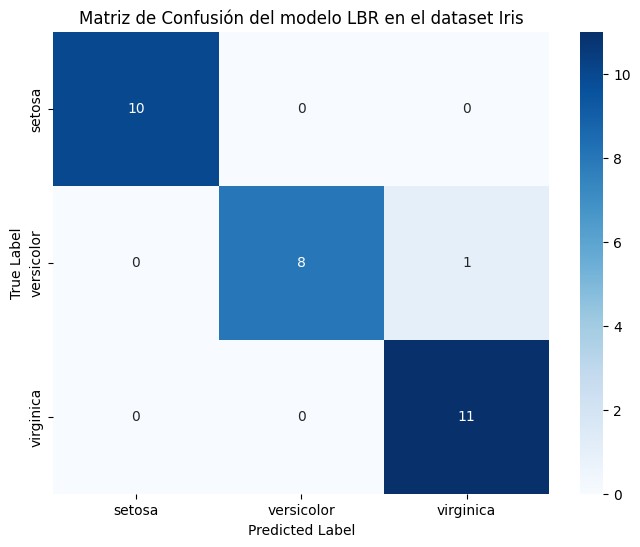

In [ ]:
# Utilizamos el modelo entrenado para predecir las etiquetas del conjunto de validación discretizado del dataset Iris
y_pred_iris_lbr = lbr_model_iris.predict(X_valid_iris_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_iris_lbr = accuracy_score(y_valid_iris, y_pred_iris_lbr)
print("Validation accuracy del modelo LBR en el dataset Iris:", accuracy_iris_lbr)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo LBR en el dataset Iris
precision_iris_lbr = precision_score(y_valid_iris, y_pred_iris_lbr, average='macro')
print("Precision del modelo LBR en el dataset Iris:", precision_iris_lbr)

recall_iris_lbr = recall_score(y_valid_iris, y_pred_iris_lbr, average='macro')
print("Recall del modelo LBR en el dataset Iris:", recall_iris_lbr)

f1_iris_lbr = f1_score(y_valid_iris, y_pred_iris_lbr, average='macro')
print("F1-Score del modelo LBR en el dataset Iris:", f1_iris_lbr)

# Generamos y mostramos el reporte de clasificación del modelo LBR en el dataset Iris
class_report_iris_lbr = classification_report(y_valid_iris, y_pred_iris_lbr)
print("Reporte de Clasificación del modelo LBR en el dataset Iris:\n", class_report_iris_lbr)

# Generamos y mostramos la matriz de confusión del modelo LBR en el dataset Iris
plot_confusion_matrix(y_valid_iris, y_pred_iris_lbr, class_names_iris, title='Matriz de Confusión del modelo LBR en el dataset Iris')

### **4.3.2. Dataset Wine**

In [ ]:
# Creamos una instancia del modelo LBR
lbr_model_wine = LBR()

# Ajustamos el modelo a los datos de entrenamiento discretizados del dataset Wine
lbr_model_wine.fit(X_train_wine_discretizado, y_train_wine)

LBR()

Validation accuracy del modelo LBR en el dataset Wine: 0.9722222222222222
Precision del modelo LBR en el dataset Wine: 0.9777777777777779
Recall del modelo LBR en el dataset Wine: 0.9761904761904763
F1-Score del modelo LBR en el dataset Wine: 0.9761600681140911
Reporte de Clasificación del modelo LBR en el dataset Wine:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



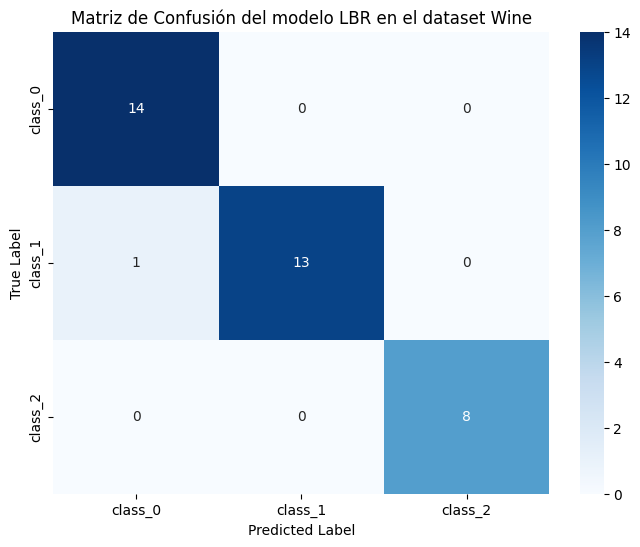

In [ ]:
# Utilizamos el modelo entrenado para predecir las etiquetas del conjunto de validación discretizado del dataset Wine
y_pred_wine_lbr = lbr_model_wine.predict(X_valid_wine_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_wine_lbr = accuracy_score(y_valid_wine, y_pred_wine_lbr)
print("Validation accuracy del modelo LBR en el dataset Wine:", accuracy_wine_lbr)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo LBR en el dataset Wine
precision_wine_lbr = precision_score(y_valid_wine, y_pred_wine_lbr, average='macro')
print("Precision del modelo LBR en el dataset Wine:", precision_wine_lbr)

recall_wine_lbr = recall_score(y_valid_wine, y_pred_wine_lbr, average='macro')
print("Recall del modelo LBR en el dataset Wine:", recall_wine_lbr)

f1_wine_lbr = f1_score(y_valid_wine, y_pred_wine_lbr, average='macro')
print("F1-Score del modelo LBR en el dataset Wine:", f1_wine_lbr)

# Generamos y mostramos el reporte de clasificación del modelo LBR en el dataset Wine
class_report_wine_lbr = classification_report(y_valid_wine, y_pred_wine_lbr)
print("Reporte de Clasificación del modelo LBR en el dataset Wine:\n", class_report_wine_lbr)

# Generamos y mostramos la matriz de confusión del modelo LBR en el dataset Wine
plot_confusion_matrix(y_valid_wine, y_pred_wine_lbr, class_names_wine, title='Matriz de Confusión del modelo LBR en el dataset Wine')

### **4.3.3. Dataset Penguins**

In [ ]:
# Creamos una instancia del modelo LBR
lbr_model_penguins = LBR()

# Ajustamos el modelo a los datos de entrenamiento discretizados del dataset Penguins
lbr_model_penguins.fit(X_train_penguins_discretizado, y_train_penguins)

LBR()

Validation accuracy del modelo LBR en el dataset Penguins: 0.9850746268656716
Precision del modelo LBR en el dataset Penguins: 0.9761904761904763
Recall del modelo LBR en el dataset Penguins: 0.989247311827957
F1-Score del modelo LBR en el dataset Penguins: 0.9821898401133374
Reporte de Clasificación del modelo LBR en el dataset Penguins:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



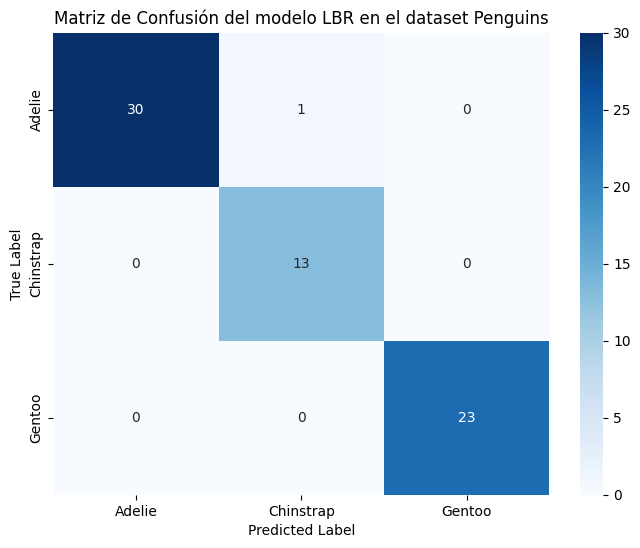

In [ ]:
# Utilizamos el modelo entrenado para predecir las etiquetas del conjunto de validación discretizado del dataset Penguins
y_pred_penguins_lbr = lbr_model_penguins.predict(X_valid_penguins_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_penguins_lbr = accuracy_score(y_valid_penguins, y_pred_penguins_lbr)
print("Validation accuracy del modelo LBR en el dataset Penguins:", accuracy_penguins_lbr)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo LBR en el dataset Penguins
precision_penguins_lbr = precision_score(y_valid_penguins, y_pred_penguins_lbr, average='macro')
print("Precision del modelo LBR en el dataset Penguins:", precision_penguins_lbr)

recall_penguins_lbr = recall_score(y_valid_penguins, y_pred_penguins_lbr, average='macro')
print("Recall del modelo LBR en el dataset Penguins:", recall_penguins_lbr)

f1_penguins_lbr = f1_score(y_valid_penguins, y_pred_penguins_lbr, average='macro')
print("F1-Score del modelo LBR en el dataset Penguins:", f1_penguins_lbr)

# Generamos y mostramos el reporte de clasificación del modelo LBR en el dataset Penguins
class_report_penguins_lbr = classification_report(y_valid_penguins, y_pred_penguins_lbr)
print("Reporte de Clasificación del modelo LBR en el dataset Penguins:\n", class_report_penguins_lbr)

# Generamos y mostramos la matriz de confusión del modelo LBR en el dataset Penguins
plot_confusion_matrix(y_valid_penguins, y_pred_penguins_lbr, class_names_penguins, title='Matriz de Confusión del modelo LBR en el dataset Penguins')

### **4.3.4. Dataset Tips**

In [ ]:
# Creamos una instancia del modelo LBR
lbr_model_tips = LBR()

# Ajustamos el modelo a los datos de entrenamiento discretizados del dataset Tips
lbr_model_tips.fit(X_train_tips_discretizado, y_train_tips)

LBR()

Validation accuracy del modelo LBR en el dataset Tips: 0.9795918367346939
Precision del modelo LBR en el dataset Tips: 0.96875
Recall del modelo LBR en el dataset Tips: 0.9852941176470589
F1-Score del modelo LBR en el dataset Tips: 0.9764082811747713
Reporte de Clasificación del modelo LBR en el dataset Tips:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.94      1.00      0.97        15

    accuracy                           0.98        49
   macro avg       0.97      0.99      0.98        49
weighted avg       0.98      0.98      0.98        49



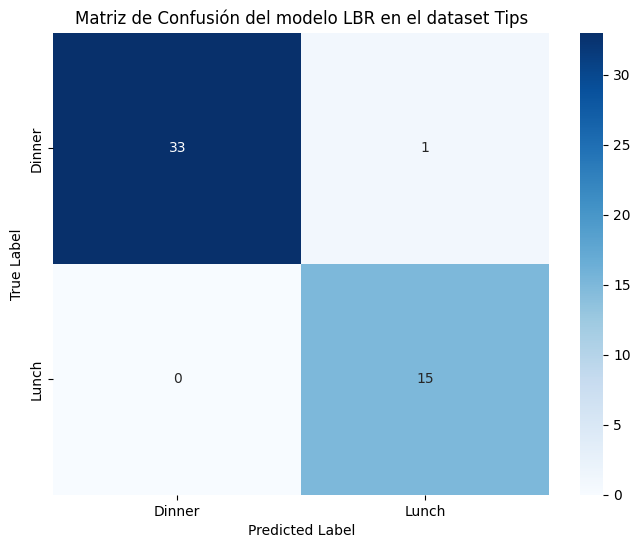

In [ ]:
# Utilizamos el modelo entrenado para predecir las etiquetas del conjunto de validación discretizado del dataset Tips
y_pred_tips_lbr = lbr_model_tips.predict(X_valid_tips_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_tips_lbr = accuracy_score(y_valid_tips, y_pred_tips_lbr)
print("Validation accuracy del modelo LBR en el dataset Tips:", accuracy_tips_lbr)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo LBR en el dataset Tips
precision_tips_lbr = precision_score(y_valid_tips, y_pred_tips_lbr, average='macro')
print("Precision del modelo LBR en el dataset Tips:", precision_tips_lbr)

recall_tips_lbr = recall_score(y_valid_tips, y_pred_tips_lbr, average='macro')
print("Recall del modelo LBR en el dataset Tips:", recall_tips_lbr)

f1_tips_lbr = f1_score(y_valid_tips, y_pred_tips_lbr, average='macro')
print("F1-Score del modelo LBR en el dataset Tips:", f1_tips_lbr)

# Generamos y mostramos el reporte de clasificación del modelo LBR en el dataset Tips
class_report_tips_lbr = classification_report(y_valid_tips, y_pred_tips_lbr)
print("Reporte de Clasificación del modelo LBR en el dataset Tips:\n", class_report_tips_lbr)

# Generamos y mostramos la matriz de confusión del modelo LBR en el dataset Tips
plot_confusion_matrix(y_valid_tips, y_pred_tips_lbr, class_names_tips, title='Matriz de Confusión del modelo LBR en el dataset Tips')

## **4.4. Experimentación con Otros Algoritmos**

Vamos a comparar nuestro algoritmo LBR implementado con los siguientes cuatro algoritmos:

- **Random Forest:** Algoritmo de aprendizaje supervisado que pertenece a la familia de los modelos de ensamblaje. Se basa en la construcción de un conjunto de árboles de decisión, cada uno entrenado con una muestra aleatoria de los datos de entrenamiento. Al realizar predicciones, el algoritmo toma el voto mayoritario de los árboles para decidir la clase final, en el caso de clasificación, o el promedio de las salidas de los árboles para la regresión. Este método es conocido por su robustez y precisión, especialmente útil en situaciones donde los datos pueden tener muchas características y complejas estructuras de interacciones. Random Forest maneja bien tanto datos categóricos como continuos y ofrece un buen desempeño frente al sobreajuste, gracias a la diversidad de sus árboles componentes.

- **Naive Bayes:** Conjunto de algoritmos de clasificación basados en el teorema de Bayes, con la "ingenua" suposición de independencia entre las características. A pesar de su simplicidad, los clasificadores Naive Bayes han demostrado ser efectivos en muchas situaciones reales, especialmente en tareas de clasificación de textos y en problemas donde las dimensiones de los datos son altas en comparación con el tamaño del conjunto de datos. Este modelo es fácil de construir sin necesidad de un ajuste iterativo complicado, y puede ser sorprendentemente eficaz, especialmente bajo la suposición de que los atributos que describen las instancias son independientes entre sí. En particular, usaremos **Gaussian Naive Bayes**, el cual es una variante específica del conjunto de algoritmos de clasificación Naive Bayes que asume una distribución normal (gaussiana) de los datos continuos. Es particularmente adecuado para características que exhiben una distribución normal y, al igual que otros clasificadores Naive Bayes, opera bajo la suposición de que las características son independientes entre sí. Esta versión del Naive Bayes es especialmente utilizada en problemas de clasificación donde las características son numéricas y continuas. A pesar de su simplicidad, Gaussian Naive Bayes puede ser muy efectivo en grandes espacios de características y es notablemente rápido en comparación con algoritmos más complejos, lo que lo hace muy útil en aplicaciones como la clasificación de textos y en situaciones donde la velocidad de predicción es crítica.

- **k-Nearest Neighbors (k-NN):** Algoritmo de aprendizaje basado en instancias que no asume ningún modelo a priori sobre la distribución de los datos. Funciona simplemente almacenando todas las instancias de entrenamiento y clasificándolas en función de una medida de similitud, como la distancia euclidiana, durante la fase de predicción. Para una nueva instancia, el algoritmo busca los K vecinos más cercanos entre los datos de entrenamiento, y la salida se determina por voto mayoritario, para clasificación, o por el promedio, para regresión. K-NN es muy intuitivo y fácil de implementar, pero puede volverse computacionalmente costoso a medida que crece el tamaño del conjunto de datos.

- **XGBoost (Extreme Gradient Boosting):** Algoritmo de optimización de gradientes que ha ganado popularidad por su eficacia en competiciones de ciencia de datos. XGBoost es una implementación avanzada de árboles de decisión aplicados en el marco de boosting, optimizando tanto objetivos computacionales como de predicción. Ofrece una rápida y eficaz ejecución de árboles de decisión, administrados en un enfoque de boosting, lo que permite mejorar modelos secuencialmente en cada iteración. Este algoritmo es altamente configurable y puede manejar diversas funciones de pérdida y ajustes de regularización, haciéndolo adaptable a una amplia gama de problemas de clasificación y regresión, al tiempo que proporciona facilidades para manejar el sobreajuste.

### **4.4.1. Random Forest**

In [ ]:
# Definición de la cuadrícula de parámetros para el modelo RandomForestClassifier
# 'n_estimators' indica la cantidad de árboles en el bosque
# 'max_depth' define la profundidad máxima de los árboles
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

#### **4.4.1.1. Dataset Iris**

In [ ]:
# Inicializamos el clasificador Random Forest con un estado aleatorio para reproducibilidad
rf_model_iris = RandomForestClassifier(random_state=42)

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
rf_iris_grid_search = GridSearchCV(estimator=rf_model_iris, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Iris para encontrar los mejores parámetros
rf_iris_grid_search.fit(X_train_iris_discretizado, y_train_iris)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo Random Forest en el dataset Iris
print("Mejores hiperparámetros para el modelo Random Forest en el dataset Iris:", rf_iris_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para Random Forest en Iris
print("Mejor validation accuracy para el modelo Random Forest en el dataset Iris:", rf_iris_grid_search.best_score_)

Mejores hiperparámetros para el modelo Random Forest en el dataset Iris: {'max_depth': None, 'n_estimators': 100}
Mejor validation accuracy para el modelo Random Forest en el dataset Iris: 0.9166666666666666


Validation accuracy del modelo Random Forest en el dataset Iris: 0.9333333333333333
Precision del modelo Random Forest en el dataset Iris: 0.9487179487179488
Recall del modelo Random Forest en el dataset Iris: 0.9259259259259259
F1-Score del modelo Random Forest en el dataset Iris: 0.9305555555555555
Reporte de Clasificación del modelo Random Forest en el dataset Iris:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



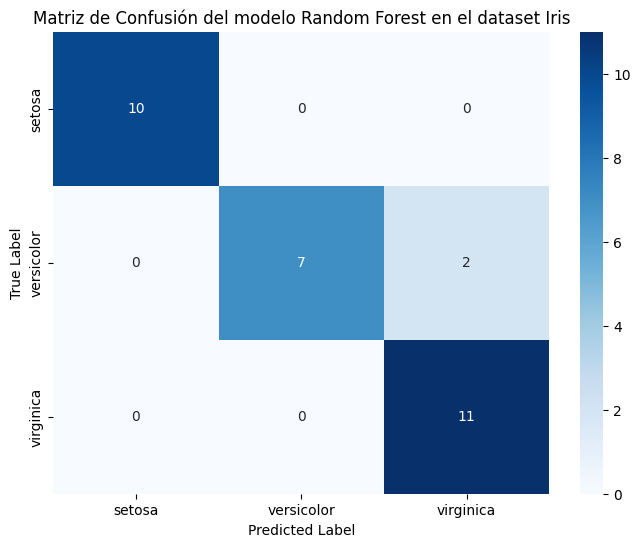

In [ ]:
# Creamos el modelo Random Forest con los mejores hiperparámetros encontrados
best_rf_model_iris = RandomForestClassifier(max_depth=None, n_estimators=100, random_state=42)

# Ajustamos el modelo Random Forest al conjunto de entrenamiento del dataset Iris discretizado
best_rf_model_iris.fit(X_train_iris_discretizado, y_train_iris)

# Realizamos predicciones en el conjunto de validación del dataset Iris discretizado
y_pred_iris_rf = best_rf_model_iris.predict(X_valid_iris_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_iris_rf = accuracy_score(y_valid_iris, y_pred_iris_rf)
print("Validation accuracy del modelo Random Forest en el dataset Iris:", accuracy_iris_rf)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Random Forest en el dataset Iris
precision_iris_rf = precision_score(y_valid_iris, y_pred_iris_rf, average='macro')
print("Precision del modelo Random Forest en el dataset Iris:", precision_iris_rf)

recall_iris_rf = recall_score(y_valid_iris, y_pred_iris_rf, average='macro')
print("Recall del modelo Random Forest en el dataset Iris:", recall_iris_rf)

f1_iris_rf = f1_score(y_valid_iris, y_pred_iris_rf, average='macro')
print("F1-Score del modelo Random Forest en el dataset Iris:", f1_iris_rf)

# Generamos y mostramos el reporte de clasificación del modelo Random Forest en el dataset Iris
class_report_iris_rf = classification_report(y_valid_iris, y_pred_iris_rf)
print("Reporte de Clasificación del modelo Random Forest en el dataset Iris:\n", class_report_iris_rf)

# Generamos y mostramos la matriz de confusión del modelo Random Forest en el dataset Iris
plot_confusion_matrix(y_valid_iris, y_pred_iris_rf, class_names_iris, title='Matriz de Confusión del modelo Random Forest en el dataset Iris')

#### **4.4.1.2. Dataset Wine**

In [ ]:
# Inicializamos el clasificador Random Forest con un estado aleatorio para reproducibilidad
rf_model_wine = RandomForestClassifier(random_state=42)

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
rf_wine_grid_search = GridSearchCV(estimator=rf_model_wine, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Wine para encontrar los mejores parámetros
rf_wine_grid_search.fit(X_train_wine_discretizado, y_train_wine)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo Random Forest en el dataset Wine
print("Mejores hiperparámetros para el modelo Random Forest en el dataset Wine:", rf_wine_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para Random Forest en Wine
print("Mejor validation accuracy para el modelo Random Forest en el dataset Wine:", rf_wine_grid_search.best_score_)

Mejores hiperparámetros para el modelo Random Forest en el dataset Wine: {'max_depth': None, 'n_estimators': 100}
Mejor validation accuracy para el modelo Random Forest en el dataset Wine: 0.9785714285714286


Validation accuracy del modelo Random Forest en el dataset Wine: 1.0
Precision del modelo Random Forest en el dataset Wine: 1.0
Recall del modelo Random Forest en el dataset Wine: 1.0
F1-Score del modelo Random Forest en el dataset Wine: 1.0
Reporte de Clasificación del modelo Random Forest en el dataset Wine:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



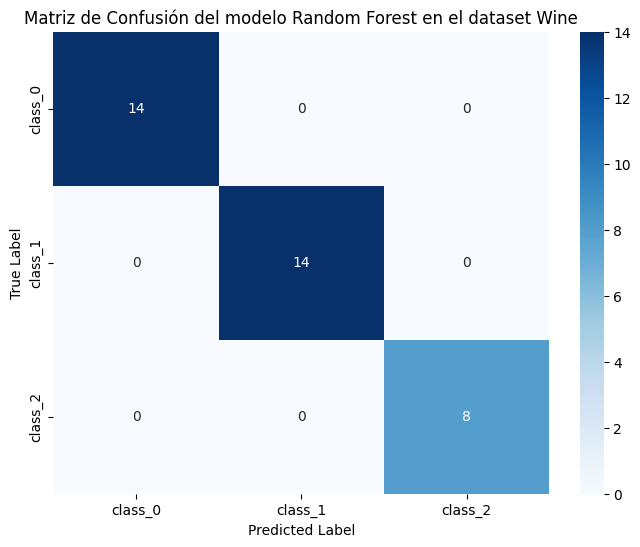

In [ ]:
# Creamos el modelo Random Forest con los mejores hiperparámetros encontrados
best_rf_model_wine = RandomForestClassifier(max_depth=None, n_estimators=100, random_state=42)

# Ajustamos el modelo Random Forest al conjunto de entrenamiento del dataset Wine discretizado
best_rf_model_wine.fit(X_train_wine_discretizado, y_train_wine)

# Realizamos predicciones en el conjunto de validación del dataset Wine discretizado
y_pred_wine_rf = best_rf_model_wine.predict(X_valid_wine_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_wine_rf = accuracy_score(y_valid_wine, y_pred_wine_rf)
print("Validation accuracy del modelo Random Forest en el dataset Wine:", accuracy_wine_rf)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Random Forest en el dataset Wine
precision_wine_rf = precision_score(y_valid_wine, y_pred_wine_rf, average='macro')
print("Precision del modelo Random Forest en el dataset Wine:", precision_wine_rf)

recall_wine_rf = recall_score(y_valid_wine, y_pred_wine_rf, average='macro')
print("Recall del modelo Random Forest en el dataset Wine:", recall_wine_rf)

f1_wine_rf = f1_score(y_valid_wine, y_pred_wine_rf, average='macro')
print("F1-Score del modelo Random Forest en el dataset Wine:", recall_wine_rf)

# Generamos y mostramos el reporte de clasificación del modelo Random Forest en el dataset Wine
class_report_wine_rf = classification_report(y_valid_wine, y_pred_wine_rf)
print("Reporte de Clasificación del modelo Random Forest en el dataset Wine:\n", class_report_wine_rf)

# Generamos y mostramos la matriz de confusión del modelo Random Forest en el dataset Wine
plot_confusion_matrix(y_valid_wine, y_pred_wine_rf, class_names_wine, title='Matriz de Confusión del modelo Random Forest en el dataset Wine')

#### **4.4.1.3. Dataset Penguins**

In [ ]:
# Inicializamos el clasificador Random Forest con un estado aleatorio para reproducibilidad
rf_model_penguins = RandomForestClassifier(random_state=42)

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
rf_penguins_grid_search = GridSearchCV(estimator=rf_model_penguins, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Penguins para encontrar los mejores parámetros
rf_penguins_grid_search.fit(X_train_penguins_discretizado, y_train_penguins)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo Random Forest en el dataset Penguins
print("Mejores hiperparámetros para el modelo Random Forest en el dataset Penguins:", rf_penguins_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para Random Forest en Penguins
print("Mejor validation accuracy para el modelo Random Forest en el dataset Penguins:", rf_penguins_grid_search.best_score_)

Mejores hiperparámetros para el modelo Random Forest en el dataset Penguins: {'max_depth': None, 'n_estimators': 100}
Mejor validation accuracy para el modelo Random Forest en el dataset Penguins: 0.9774982529699511


Validation accuracy del modelo Random Forest en el dataset Penguins: 0.9850746268656716
Precision del modelo Random Forest en el dataset Penguins: 0.9761904761904763
Recall del modelo Random Forest en el dataset Penguins: 0.989247311827957
F1-Score del modelo Random Forest en el dataset Penguins: 0.9821898401133374
Reporte de Clasificación del modelo Random Forest en el dataset Penguins:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        31
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



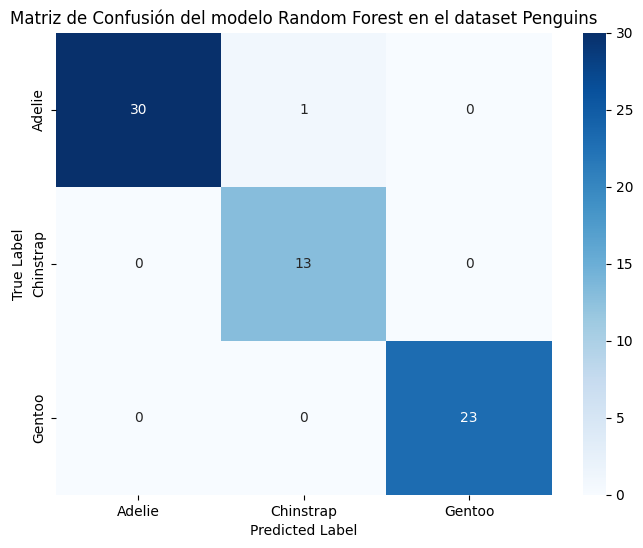

In [ ]:
# Creamos el modelo Random Forest con los mejores hiperparámetros encontrados
best_rf_model_penguins = RandomForestClassifier(max_depth=None, n_estimators=100, random_state=42)

# Ajustamos el modelo Random Forest al conjunto de entrenamiento del dataset Penguins discretizado
best_rf_model_penguins.fit(X_train_penguins_discretizado, y_train_penguins)

# Realizamos predicciones en el conjunto de validación del dataset Penguins discretizado
y_pred_penguins_rf = best_rf_model_penguins.predict(X_valid_penguins_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_penguins_rf = accuracy_score(y_valid_penguins, y_pred_penguins_rf)
print("Validation accuracy del modelo Random Forest en el dataset Penguins:", accuracy_penguins_rf)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Random Forest en el dataset Penguins
precision_penguins_rf = precision_score(y_valid_penguins, y_pred_penguins_rf, average='macro')
print("Precision del modelo Random Forest en el dataset Penguins:", precision_penguins_rf)

recall_penguins_rf = recall_score(y_valid_penguins, y_pred_penguins_rf, average='macro')
print("Recall del modelo Random Forest en el dataset Penguins:", recall_penguins_rf)

f1_penguins_rf = f1_score(y_valid_penguins, y_pred_penguins_rf, average='macro')
print("F1-Score del modelo Random Forest en el dataset Penguins:", f1_penguins_rf)

# Generamos y mostramos el reporte de clasificación del modelo Random Forest en el dataset Penguins
class_report_penguins_rf = classification_report(y_valid_penguins, y_pred_penguins_rf)
print("Reporte de Clasificación del modelo Random Forest en el dataset Penguins:\n", class_report_penguins_rf)

# Generamos y mostramos la matriz de confusión del modelo Random Forest en el dataset Penguins
plot_confusion_matrix(y_valid_penguins, y_pred_penguins_rf, class_names_penguins, title='Matriz de Confusión del modelo Random Forest en el dataset Penguins')

#### **4.4.1.4. Dataset Tips**

In [ ]:
# Inicializamos el clasificador Random Forest con un estado aleatorio para reproducibilidad
rf_model_tips = RandomForestClassifier(random_state=42)

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
rf_tips_grid_search = GridSearchCV(estimator=rf_model_tips, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Tips para encontrar los mejores parámetros
rf_tips_grid_search.fit(X_train_tips_discretizado, y_train_tips)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo Random Forest en el dataset Tips
print("Mejores hiperparámetros para el modelo Random Forest en el dataset Tips:", rf_tips_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para Random Forest en Tips
print("Mejor validation accuracy para el modelo Random Forest en el dataset Tips:", rf_tips_grid_search.best_score_)

Mejores hiperparámetros para el modelo Random Forest en el dataset Tips: {'max_depth': None, 'n_estimators': 200}
Mejor validation accuracy para el modelo Random Forest en el dataset Tips: 0.9384615384615385


Validation accuracy del modelo Random Forest en el dataset Tips: 0.9795918367346939
Precision del modelo Random Forest en el dataset Tips: 0.96875
Recall del modelo Random Forest en el dataset Tips: 0.9852941176470589
F1-Score del modelo Random Forest en el dataset Tips: 0.9764082811747713
Reporte de Clasificación del modelo Random Forest en el dataset Tips:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.94      1.00      0.97        15

    accuracy                           0.98        49
   macro avg       0.97      0.99      0.98        49
weighted avg       0.98      0.98      0.98        49



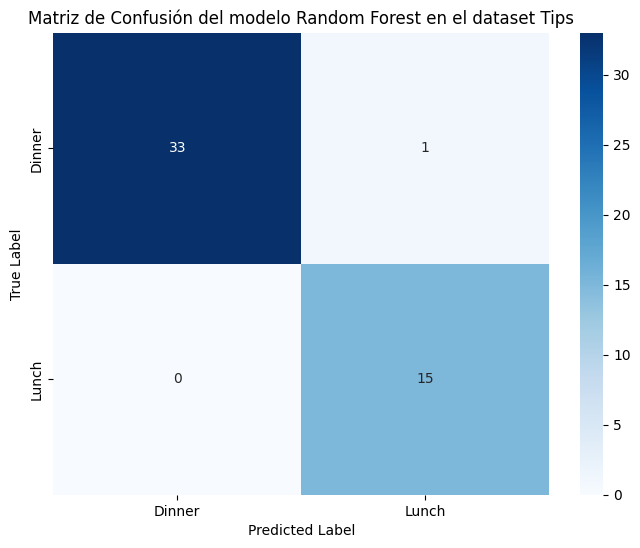

In [ ]:
# Creamos el modelo Random Forest con los mejores hiperparámetros encontrados
best_rf_model_tips = RandomForestClassifier(max_depth=None, n_estimators=200, random_state=42)

# Ajustamos el modelo Random Forest al conjunto de entrenamiento del dataset Tips discretizado
best_rf_model_tips.fit(X_train_tips_discretizado, y_train_tips)

# Realizamos predicciones en el conjunto de validación del dataset Tips discretizado
y_pred_tips_rf = best_rf_model_tips.predict(X_valid_tips_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_tips_rf = accuracy_score(y_valid_tips, y_pred_tips_rf)
print("Validation accuracy del modelo Random Forest en el dataset Tips:", accuracy_tips_rf)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Random Forest en el dataset Tips
precision_tips_rf = precision_score(y_valid_tips, y_pred_tips_rf, average='macro')
print("Precision del modelo Random Forest en el dataset Tips:", precision_tips_rf)

recall_tips_rf = recall_score(y_valid_tips, y_pred_tips_rf, average='macro')
print("Recall del modelo Random Forest en el dataset Tips:", recall_tips_rf)

f1_tips_rf = f1_score(y_valid_tips, y_pred_tips_rf, average='macro')
print("F1-Score del modelo Random Forest en el dataset Tips:", f1_tips_rf)

# Generamos y mostramos el reporte de clasificación del modelo Random Forest en el dataset Tips
class_report_tips_rf = classification_report(y_valid_tips, y_pred_tips_rf)
print("Reporte de Clasificación del modelo Random Forest en el dataset Tips:\n", class_report_tips_rf)

# Generamos y mostramos la matriz de confusión del modelo Random Forest en el dataset Tips
plot_confusion_matrix(y_valid_tips, y_pred_tips_rf, class_names_tips, title='Matriz de Confusión del modelo Random Forest en el dataset Tips')

### **4.4.2. Naive Bayes**

#### **4.4.2.1. Dataset Iris**

In [ ]:
# Inicializamos el clasificador Naive Bayes
nb_model_iris = GaussianNB()

# Ajustamos el modelo Naive Bayes a los datos de entrenamiento discretizados del dataset Iris
nb_model_iris.fit(X_train_iris_discretizado, y_train_iris)

GaussianNB()

Validation accuracy del modelo Naive Bayes en el dataset Iris: 0.9666666666666667
Precision del modelo Naive Bayes en el dataset Iris: 0.9722222222222222
Recall del modelo Naive Bayes en el dataset Iris: 0.9629629629629629
F1-Score del modelo Naive Bayes en el dataset Iris: 0.9658994032395567
Reporte de Clasificación del modelo Naive Bayes en el dataset Iris:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



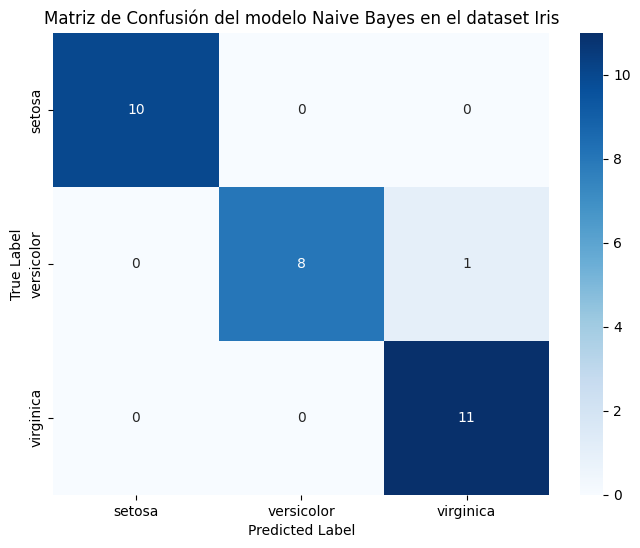

In [ ]:
# Realizamos predicciones en el conjunto de validación del dataset Iris discretizado
y_pred_iris_nb = nb_model_iris.predict(X_valid_iris_discretizado)

# Calculamos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_iris_nb = accuracy_score(y_valid_iris, y_pred_iris_nb)
print("Validation accuracy del modelo Naive Bayes en el dataset Iris:", accuracy_iris_nb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Naive Bayes en el dataset Iris
precision_iris_nb = precision_score(y_valid_iris, y_pred_iris_nb, average='macro')
print("Precision del modelo Naive Bayes en el dataset Iris:", precision_iris_nb)

recall_iris_nb = recall_score(y_valid_iris, y_pred_iris_nb, average='macro')
print("Recall del modelo Naive Bayes en el dataset Iris:", recall_iris_nb)

f1_iris_nb = f1_score(y_valid_iris, y_pred_iris_nb, average='macro')
print("F1-Score del modelo Naive Bayes en el dataset Iris:", f1_iris_nb)

# Generamos y mostramos el reporte de clasificación del modelo Naive Bayes en el dataset Iris
class_report_iris_nb = classification_report(y_valid_iris, y_pred_iris_nb)
print("Reporte de Clasificación del modelo Naive Bayes en el dataset Iris:\n", class_report_iris_nb)

# Generamos y mostramos la matriz de confusión del modelo Naive Bayes en el dataset Iris
plot_confusion_matrix(y_valid_iris, y_pred_iris_nb, class_names_iris, title='Matriz de Confusión del modelo Naive Bayes en el dataset Iris')

#### **4.4.2.2. Dataset Wine**

In [ ]:
# Inicializamos el clasificador Naive Bayes
nb_model_wine = GaussianNB()

# Ajustamos el modelo Naive Bayes a los datos de entrenamiento discretizados del dataset Wine
nb_model_wine.fit(X_train_wine_discretizado, y_train_wine)

GaussianNB()

Validation accuracy del modelo Naive Bayes en el dataset Wine: 1.0
Precision del modelo Naive Bayes en el dataset Wine: 1.0
Recall del modelo Naive Bayes en el dataset Wine: 1.0
F1-Score del modelo Naive Bayes en el dataset Wine: 1.0
Reporte de Clasificación del modelo Naive Bayes en el dataset Wine:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



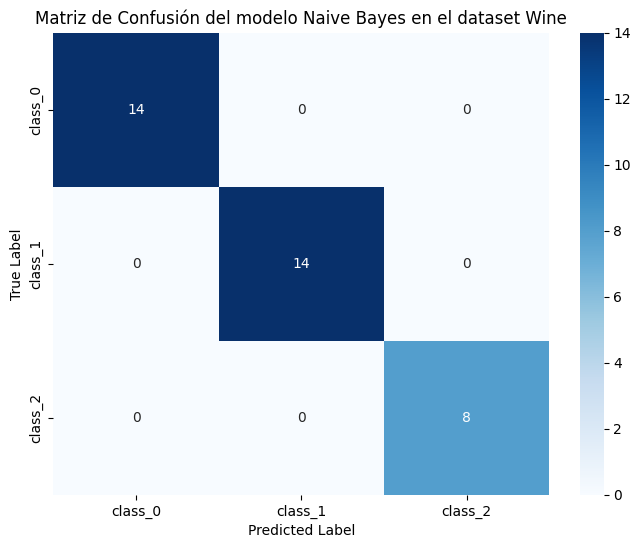

In [ ]:
# Realizamos predicciones en el conjunto de validación del dataset Wine discretizado
y_pred_wine_nb = nb_model_wine.predict(X_valid_wine_discretizado)

# Calculamos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_wine_nb = accuracy_score(y_valid_wine, y_pred_wine_nb)
print("Validation accuracy del modelo Naive Bayes en el dataset Wine:", accuracy_wine_nb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Naive Bayes en el dataset Wine
precision_wine_nb = precision_score(y_valid_wine, y_pred_wine_nb, average='macro')
print("Precision del modelo Naive Bayes en el dataset Wine:", precision_wine_nb)

recall_wine_nb = recall_score(y_valid_wine, y_pred_wine_nb, average='macro')
print("Recall del modelo Naive Bayes en el dataset Wine:", recall_wine_nb)

f1_wine_nb = f1_score(y_valid_wine, y_pred_wine_nb, average='macro')
print("F1-Score del modelo Naive Bayes en el dataset Wine:", f1_wine_nb)

# Generamos y mostramos el reporte de clasificación del modelo Naive Bayes en el dataset Wine
class_report_wine_nb = classification_report(y_valid_wine, y_pred_wine_nb)
print("Reporte de Clasificación del modelo Naive Bayes en el dataset Wine:\n", class_report_wine_nb)

# Generamos y mostramos la matriz de confusión del modelo Naive Bayes en el dataset Wine
plot_confusion_matrix(y_valid_wine, y_pred_wine_nb, class_names_wine, title='Matriz de Confusión del modelo Naive Bayes en el dataset Wine')

#### **4.4.2.3. Dataset Penguins**

In [ ]:
# Inicializamos el clasificador Naive Bayes
nb_model_penguins = GaussianNB()

# Ajustamos el modelo Naive Bayes a los datos de entrenamiento discretizados del dataset Penguins
nb_model_penguins.fit(X_train_penguins_discretizado, y_train_penguins)

GaussianNB()

Validation accuracy del modelo Naive Bayes en el dataset Penguins: 0.8507462686567164
Precision del modelo Naive Bayes en el dataset Penguins: 0.8448717948717949
Recall del modelo Naive Bayes en el dataset Penguins: 0.8924731182795699
F1-Score del modelo Naive Bayes en el dataset Penguins: 0.8447822019250589
Reporte de Clasificación del modelo Naive Bayes en el dataset Penguins:
               precision    recall  f1-score   support

           0       1.00      0.68      0.81        31
           1       0.65      1.00      0.79        13
           2       0.88      1.00      0.94        23

    accuracy                           0.85        67
   macro avg       0.84      0.89      0.84        67
weighted avg       0.89      0.85      0.85        67



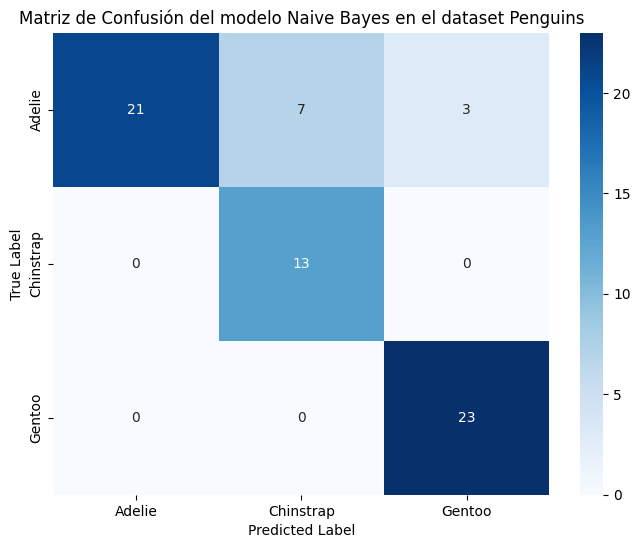

In [ ]:
# Realizamos predicciones en el conjunto de validación del dataset Penguins discretizado
y_pred_penguins_nb = nb_model_penguins.predict(X_valid_penguins_discretizado)

# Calculamos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_penguins_nb = accuracy_score(y_valid_penguins, y_pred_penguins_nb)
print("Validation accuracy del modelo Naive Bayes en el dataset Penguins:", accuracy_penguins_nb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Naive Bayes en el dataset Penguins
precision_penguins_nb = precision_score(y_valid_penguins, y_pred_penguins_nb, average='macro')
print("Precision del modelo Naive Bayes en el dataset Penguins:", precision_penguins_nb)

recall_penguins_nb = recall_score(y_valid_penguins, y_pred_penguins_nb, average='macro')
print("Recall del modelo Naive Bayes en el dataset Penguins:", recall_penguins_nb)

f1_penguins_nb = f1_score(y_valid_penguins, y_pred_penguins_nb, average='macro')
print("F1-Score del modelo Naive Bayes en el dataset Penguins:", f1_penguins_nb)

# Generamos y mostramos el reporte de clasificación del modelo Naive Bayes en el dataset Penguins
class_report_penguins_nb = classification_report(y_valid_penguins, y_pred_penguins_nb)
print("Reporte de Clasificación del modelo Naive Bayes en el dataset Penguins:\n", class_report_penguins_nb)

# Generamos y mostramos la matriz de confusión del modelo Naive Bayes en el dataset Penguins
plot_confusion_matrix(y_valid_penguins, y_pred_penguins_nb, class_names_penguins, title='Matriz de Confusión del modelo Naive Bayes en el dataset Penguins')

#### **4.4.2.4. Dataset Tips**

In [ ]:
# Inicializamos el clasificador Naive Bayes
nb_model_tips = GaussianNB()

# Ajustamos el modelo Naive Bayes a los datos de entrenamiento discretizados del dataset Tips
nb_model_tips.fit(X_train_tips_discretizado, y_train_tips)

GaussianNB()

Validation accuracy del modelo Naive Bayes en el dataset Tips: 0.9591836734693877
Precision del modelo Naive Bayes en el dataset Tips: 0.9411764705882353
Recall del modelo Naive Bayes en el dataset Tips: 0.9705882352941176
F1-Score del modelo Naive Bayes en el dataset Tips: 0.9535984848484849
Reporte de Clasificación del modelo Naive Bayes en el dataset Tips:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       0.88      1.00      0.94        15

    accuracy                           0.96        49
   macro avg       0.94      0.97      0.95        49
weighted avg       0.96      0.96      0.96        49



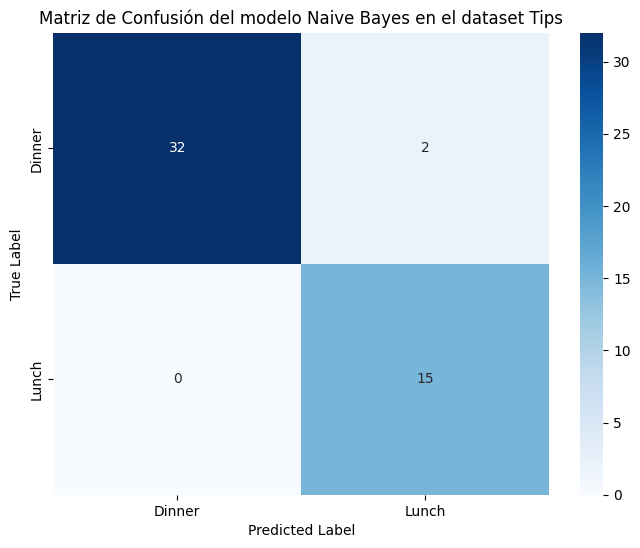

In [ ]:
# Realizamos predicciones en el conjunto de validación del dataset Tips discretizado
y_pred_tips_nb = nb_model_tips.predict(X_valid_tips_discretizado)

# Calculamos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_tips_nb = accuracy_score(y_valid_tips, y_pred_tips_nb)
print("Validation accuracy del modelo Naive Bayes en el dataset Tips:", accuracy_tips_nb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo Naive Bayes en el dataset Tips
precision_tips_nb = precision_score(y_valid_tips, y_pred_tips_nb, average='macro')
print("Precision del modelo Naive Bayes en el dataset Tips:", precision_tips_nb)

recall_tips_nb = recall_score(y_valid_tips, y_pred_tips_nb, average='macro')
print("Recall del modelo Naive Bayes en el dataset Tips:", recall_tips_nb)

f1_tips_nb = f1_score(y_valid_tips, y_pred_tips_nb, average='macro')
print("F1-Score del modelo Naive Bayes en el dataset Tips:", f1_tips_nb)

# Generamos y mostramos el reporte de clasificación del modelo Naive Bayes en el dataset Tips
class_report_tips_nb = classification_report(y_valid_tips, y_pred_tips_nb)
print("Reporte de Clasificación del modelo Naive Bayes en el dataset Tips:\n", class_report_tips_nb)

# Generamos y mostramos la matriz de confusión del modelo Naive Bayes en el dataset Tips
plot_confusion_matrix(y_valid_tips, y_pred_tips_nb, class_names_tips, title='Matriz de Confusión del modelo Naive Bayes en el dataset Tips')

### **4.4.3. k-NN**

In [ ]:
# Definición de la cuadrícula de parámetros para el modelo KNeighborsClassifier
# 'n_neighbors' indica el número de vecinos más cercanos a considerar
# 'metric' define las métricas de distancia utilizadas para el cálculo de vecinos
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

#### **4.4.3.1. Dataset Iris**

In [ ]:
# Inicializamos el clasificador k-NN
knn_model_iris = KNeighborsClassifier()

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
knn_iris_grid_search = GridSearchCV(estimator=knn_model_iris, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Iris para encontrar los mejores parámetros
knn_iris_grid_search.fit(X_train_iris_discretizado, y_train_iris)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo k-NN en el dataset Iris
print("Mejores hiperparámetros para el modelo k-NN en el dataset Iris:", knn_iris_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para k-NN en Iris
print("Mejor validation accuracy para el modelo k-NN en el dataset Iris:", knn_iris_grid_search.best_score_)

Mejores hiperparámetros para el modelo k-NN en el dataset Iris: {'metric': 'manhattan', 'n_neighbors': 11}
Mejor validation accuracy para el modelo k-NN en el dataset Iris: 0.95


Validation accuracy del modelo k-NN en el dataset Iris: 0.8333333333333334
Precision del modelo k-NN en el dataset Iris: 0.8958333333333334
Recall del modelo k-NN en el dataset Iris: 0.8148148148148149
F1-Score del modelo k-NN en el dataset Iris: 0.8100664767331435
Reporte de Clasificación del modelo k-NN en el dataset Iris:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30



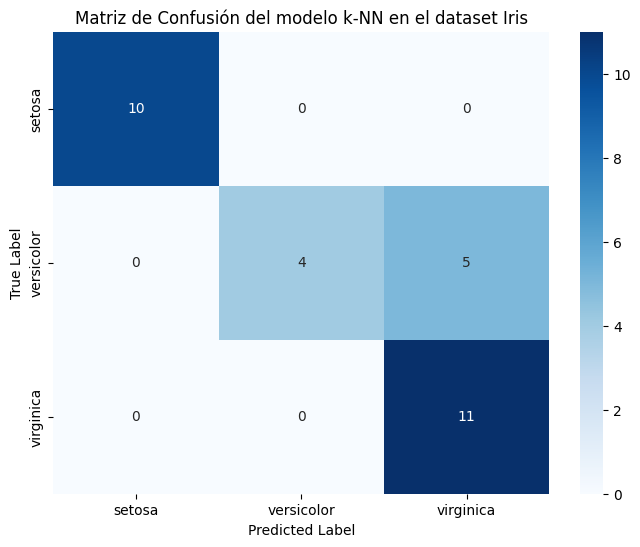

In [ ]:
# Creamos el modelo k-NN con los mejores hiperparámetros encontrados
best_knn_model_iris = KNeighborsClassifier(metric='manhattan', n_neighbors=11)

# Ajustamos el modelo k-NN al conjunto de entrenamiento del dataset Iris discretizado
best_knn_model_iris.fit(X_train_iris_discretizado, y_train_iris)

# Realizamos predicciones en el conjunto de validación del dataset Iris discretizado
y_pred_iris_knn = best_knn_model_iris.predict(X_valid_iris_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_iris_knn = accuracy_score(y_valid_iris, y_pred_iris_knn)
print("Validation accuracy del modelo k-NN en el dataset Iris:", accuracy_iris_knn)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo k-NN en el dataset Iris
precision_iris_knn = precision_score(y_valid_iris, y_pred_iris_knn, average='macro')
print("Precision del modelo k-NN en el dataset Iris:", precision_iris_knn)

recall_iris_knn = recall_score(y_valid_iris, y_pred_iris_knn, average='macro')
print("Recall del modelo k-NN en el dataset Iris:", recall_iris_knn)

f1_iris_knn = f1_score(y_valid_iris, y_pred_iris_knn, average='macro')
print("F1-Score del modelo k-NN en el dataset Iris:", f1_iris_knn)

# Generamos y mostramos el reporte de clasificación del modelo k-NN en el dataset Iris
class_report_iris_knn = classification_report(y_valid_iris, y_pred_iris_knn)
print("Reporte de Clasificación del modelo k-NN en el dataset Iris:\n", class_report_iris_knn)

# Generamos y mostramos la matriz de confusión del modelo k-NN en el dataset Iris
plot_confusion_matrix(y_valid_iris, y_pred_iris_knn, class_names_iris, title='Matriz de Confusión del modelo k-NN en el dataset Iris')

#### **4.4.3.2. Dataset Wine**

In [ ]:
# Inicializamos el clasificador k-NN
knn_model_wine = KNeighborsClassifier()

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
knn_wine_grid_search = GridSearchCV(estimator=knn_model_wine, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Wine para encontrar los mejores parámetros
knn_wine_grid_search.fit(X_train_wine_discretizado, y_train_wine)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo k-NN en el dataset Wine
print("Mejores hiperparámetros para el modelo k-NN en el dataset Wine:", knn_wine_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para k-NN en Wine
print("Mejor validation accuracy para el modelo k-NN en el dataset Wine:", knn_wine_grid_search.best_score_)

Mejores hiperparámetros para el modelo k-NN en el dataset Wine: {'metric': 'euclidean', 'n_neighbors': 9}
Mejor validation accuracy para el modelo k-NN en el dataset Wine: 0.9785714285714286


Validation accuracy del modelo k-NN en el dataset Wine: 0.9444444444444444
Precision del modelo k-NN en el dataset Wine: 0.9407407407407407
Recall del modelo k-NN en el dataset Wine: 0.9523809523809524
F1-Score del modelo k-NN en el dataset Wine: 0.9432568783481562
Reporte de Clasificación del modelo k-NN en el dataset Wine:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.86      0.92        14
           2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



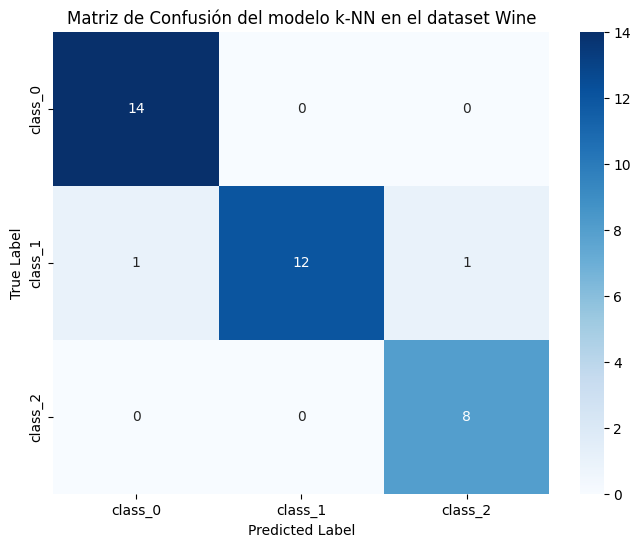

In [ ]:
# Creamos el modelo k-NN con los mejores hiperparámetros encontrados
best_knn_model_wine = KNeighborsClassifier(metric='euclidean', n_neighbors=9)

# Ajustamos el modelo k-NN al conjunto de entrenamiento del dataset Wine discretizado
best_knn_model_wine.fit(X_train_wine_discretizado, y_train_wine)

# Realizamos predicciones en el conjunto de validación del dataset Wine discretizado
y_pred_wine_knn = best_knn_model_wine.predict(X_valid_wine_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_wine_knn = accuracy_score(y_valid_wine, y_pred_wine_knn)
print("Validation accuracy del modelo k-NN en el dataset Wine:", accuracy_wine_knn)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo k-NN en el dataset Wine
precision_wine_knn = precision_score(y_valid_wine, y_pred_wine_knn, average='macro')
print("Precision del modelo k-NN en el dataset Wine:", precision_wine_knn)

recall_wine_knn = recall_score(y_valid_wine, y_pred_wine_knn, average='macro')
print("Recall del modelo k-NN en el dataset Wine:", recall_wine_knn)

f1_wine_knn = f1_score(y_valid_wine, y_pred_wine_knn, average='macro')
print("F1-Score del modelo k-NN en el dataset Wine:", f1_wine_knn)

# Generamos y mostramos el reporte de clasificación del modelo k-NN en el dataset Wine
class_report_wine_knn = classification_report(y_valid_wine, y_pred_wine_knn)
print("Reporte de Clasificación del modelo k-NN en el dataset Wine:\n", class_report_wine_knn)

# Generamos y mostramos la matriz de confusión del modelo k-NN en el dataset Wine
plot_confusion_matrix(y_valid_wine, y_pred_wine_knn, class_names_wine, title='Matriz de Confusión del modelo k-NN en el dataset Wine')

#### **4.4.3.3. Dataset Penguins**

In [ ]:
# Inicializamos el clasificador k-NN
knn_model_penguins = KNeighborsClassifier()

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
knn_penguins_grid_search = GridSearchCV(estimator=knn_model_penguins, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Penguins para encontrar los mejores parámetros
knn_penguins_grid_search.fit(X_train_penguins_discretizado, y_train_penguins)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo k-NN en el dataset Penguins
print("Mejores hiperparámetros para el modelo k-NN en el dataset Penguins:", knn_penguins_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para k-NN en Penguins
print("Mejor validation accuracy para el modelo k-NN en el dataset Penguins:", knn_penguins_grid_search.best_score_)

Mejores hiperparámetros para el modelo k-NN en el dataset Penguins: {'metric': 'euclidean', 'n_neighbors': 9}
Mejor validation accuracy para el modelo k-NN en el dataset Penguins: 0.9774982529699511


Validation accuracy del modelo k-NN en el dataset Penguins: 1.0
Precision del modelo k-NN en el dataset Penguins: 1.0
Recall del modelo k-NN en el dataset Penguins: 1.0
F1-Score del modelo k-NN en el dataset Penguins: 1.0
Reporte de Clasificación del modelo k-NN en el dataset Penguins:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



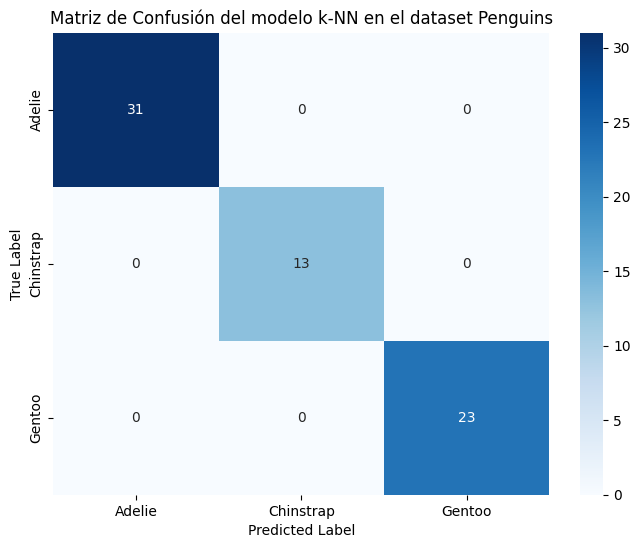

In [ ]:
# Creamos el modelo k-NN con los mejores hiperparámetros encontrados
best_knn_model_penguins = KNeighborsClassifier(metric='euclidean', n_neighbors=9)

# Ajustamos el modelo k-NN al conjunto de entrenamiento del dataset Penguins discretizado
best_knn_model_penguins.fit(X_train_penguins_discretizado, y_train_penguins)

# Realizamos predicciones en el conjunto de validación del dataset Penguins discretizado
y_pred_penguins_knn = best_knn_model_penguins.predict(X_valid_penguins_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_penguins_knn = accuracy_score(y_valid_penguins, y_pred_penguins_knn)
print("Validation accuracy del modelo k-NN en el dataset Penguins:", accuracy_penguins_knn)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo k-NN en el dataset Penguins
precision_penguins_knn = precision_score(y_valid_penguins, y_pred_penguins_knn, average='macro')
print("Precision del modelo k-NN en el dataset Penguins:", precision_penguins_knn)

recall_penguins_knn = recall_score(y_valid_penguins, y_pred_penguins_knn, average='macro')
print("Recall del modelo k-NN en el dataset Penguins:", recall_penguins_knn)

f1_penguins_knn = f1_score(y_valid_penguins, y_pred_penguins_knn, average='macro')
print("F1-Score del modelo k-NN en el dataset Penguins:", f1_penguins_knn)

# Generamos y mostramos el reporte de clasificación del modelo k-NN en el dataset Penguins
class_report_penguins_knn = classification_report(y_valid_penguins, y_pred_penguins_knn)
print("Reporte de Clasificación del modelo k-NN en el dataset Penguins:\n", class_report_penguins_knn)

# Generamos y mostramos la matriz de confusión del modelo k-NN en el dataset Penguins
plot_confusion_matrix(y_valid_penguins, y_pred_penguins_knn, class_names_penguins, title='Matriz de Confusión del modelo k-NN en el dataset Penguins')

#### **4.4.3.4. Dataset Tips**

In [ ]:
# Inicializamos el clasificador k-NN
knn_model_tips = KNeighborsClassifier()

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
knn_tips_grid_search = GridSearchCV(estimator=knn_model_tips, param_grid=param_grid_knn, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Tips para encontrar los mejores parámetros
knn_tips_grid_search.fit(X_train_tips_discretizado, y_train_tips)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo k-NN en el dataset Tips
print("Mejores hiperparámetros para el modelo k-NN en el dataset Tips:", knn_tips_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para k-NN en Tips
print("Mejor validation accuracy para el modelo k-NN en el dataset Tips:", knn_tips_grid_search.best_score_)

Mejores hiperparámetros para el modelo k-NN en el dataset Tips: {'metric': 'euclidean', 'n_neighbors': 3}
Mejor validation accuracy para el modelo k-NN en el dataset Tips: 0.9333333333333333


Validation accuracy del modelo k-NN en el dataset Tips: 0.9591836734693877
Precision del modelo k-NN en el dataset Tips: 0.9411764705882353
Recall del modelo k-NN en el dataset Tips: 0.9705882352941176
F1-Score del modelo k-NN en el dataset Tips: 0.9535984848484849
Reporte de Clasificación del modelo k-NN en el dataset Tips:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97        34
           1       0.88      1.00      0.94        15

    accuracy                           0.96        49
   macro avg       0.94      0.97      0.95        49
weighted avg       0.96      0.96      0.96        49



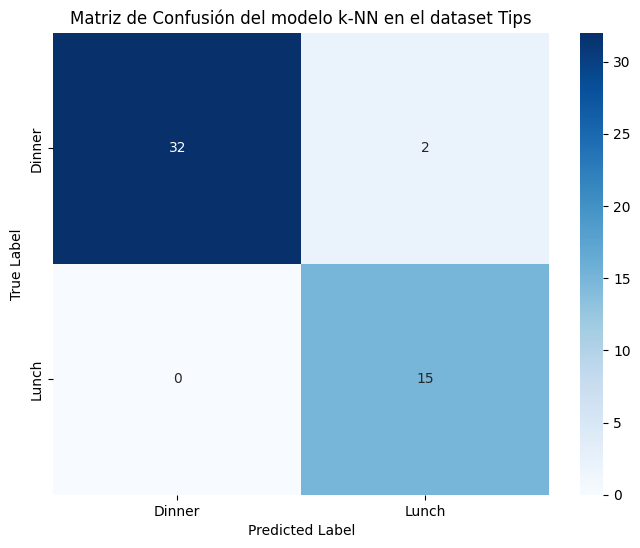

In [ ]:
# Creamos el modelo k-NN con los mejores hiperparámetros encontrados
best_knn_model_tips = KNeighborsClassifier(metric='euclidean', n_neighbors=3)

# Ajustamos el modelo k-NN al conjunto de entrenamiento del dataset Tips discretizado
best_knn_model_tips.fit(X_train_tips_discretizado, y_train_tips)

# Realizamos predicciones en el conjunto de validación del dataset Tips discretizado
y_pred_tips_knn = best_knn_model_tips.predict(X_valid_tips_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_tips_knn = accuracy_score(y_valid_tips, y_pred_tips_knn)
print("Validation accuracy del modelo k-NN en el dataset Tips:", accuracy_tips_knn)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo k-NN en el dataset Tips
precision_tips_knn = precision_score(y_valid_tips, y_pred_tips_knn, average='macro')
print("Precision del modelo k-NN en el dataset Tips:", precision_tips_knn)

recall_tips_knn = recall_score(y_valid_tips, y_pred_tips_knn, average='macro')
print("Recall del modelo k-NN en el dataset Tips:", recall_tips_knn)

f1_tips_knn = f1_score(y_valid_tips, y_pred_tips_knn, average='macro')
print("F1-Score del modelo k-NN en el dataset Tips:", f1_tips_knn)

# Generamos y mostramos el reporte de clasificación del modelo k-NN en el dataset Tips
class_report_tips_knn = classification_report(y_valid_tips, y_pred_tips_knn)
print("Reporte de Clasificación del modelo k-NN en el dataset Tips:\n", class_report_tips_knn)

# Generamos y mostramos la matriz de confusión del modelo k-NN en el dataset Tips
plot_confusion_matrix(y_valid_tips, y_pred_tips_knn, class_names_tips, title='Matriz de Confusión del modelo k-NN en el dataset Tips')

### **4.4.4. XGBoost**

In [ ]:
# Definición de la cuadrícula de parámetros para el modelo XGBoost
# 'n_estimators' indica la cantidad de árboles de decisión a construir en el proceso de boosting
# 'learning_rate' define la tasa de aprendizaje para ajustar la contribución de cada árbol
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2]
}

#### **4.4.4.1. Dataset Iris**

In [ ]:
# Inicializamos el clasificador XGBoost
xgb_model_iris = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
xgb_iris_grid_search = GridSearchCV(estimator=xgb_model_iris, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Iris para encontrar los mejores parámetros
xgb_iris_grid_search.fit(X_train_iris_discretizado, y_train_iris)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo XGBoost en el dataset Iris
print("Mejores hiperparámetros para el modelo XGBoost en el dataset Iris:", xgb_iris_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para XGBoost en Iris
print("Mejor validation accuracy para el modelo XGBoost en el dataset Iris:", xgb_iris_grid_search.best_score_)

Mejores hiperparámetros para el modelo XGBoost en el dataset Iris: {'learning_rate': 0.01, 'n_estimators': 50}
Mejor validation accuracy para el modelo XGBoost en el dataset Iris: 0.9166666666666666


Validation accuracy del modelo XGBoost en el dataset Iris: 0.9666666666666667
Precision del modelo XGBoost en el dataset Iris: 0.9722222222222222
Recall del modelo XGBoost en el dataset Iris: 0.9629629629629629
F1-Score del modelo XGBoost en el dataset Iris: 0.9658994032395567
Reporte de Clasificación del modelo XGBoost en el dataset Iris:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



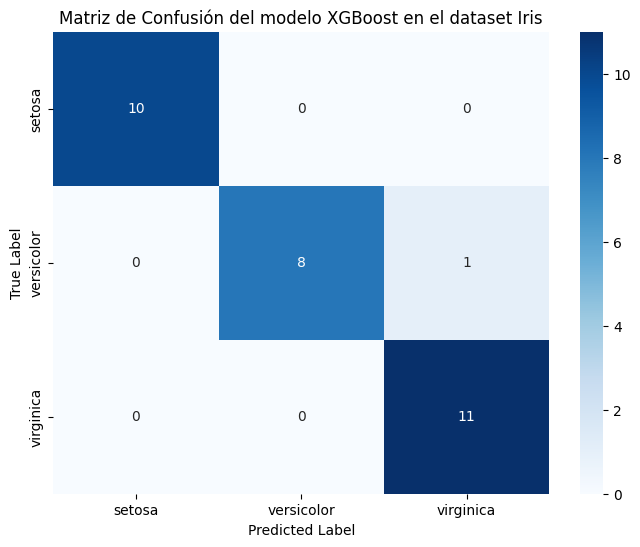

In [ ]:
# Creamos el modelo XGBoost con los mejores hiperparámetros encontrados
best_xgb_model_iris = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', learning_rate=0.01, n_estimators=50)

# Ajustamos el modelo XGBoost al conjunto de entrenamiento del dataset Iris discretizado
best_xgb_model_iris.fit(X_train_iris_discretizado, y_train_iris)

# Realizamos predicciones en el conjunto de validación del dataset Iris discretizado
y_pred_iris_xgb = best_xgb_model_iris.predict(X_valid_iris_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_iris_xgb = accuracy_score(y_valid_iris, y_pred_iris_xgb)
print("Validation accuracy del modelo XGBoost en el dataset Iris:", accuracy_iris_xgb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo XGBoost en el dataset Iris
precision_iris_xgb = precision_score(y_valid_iris, y_pred_iris_xgb, average='macro')
print("Precision del modelo XGBoost en el dataset Iris:", precision_iris_xgb)

recall_iris_xgb = recall_score(y_valid_iris, y_pred_iris_xgb, average='macro')
print("Recall del modelo XGBoost en el dataset Iris:", recall_iris_xgb)

f1_iris_xgb = f1_score(y_valid_iris, y_pred_iris_xgb, average='macro')
print("F1-Score del modelo XGBoost en el dataset Iris:", f1_iris_xgb)

# Generamos y mostramos el reporte de clasificación del modelo XGBoost en el dataset Iris
class_report_iris_xgb = classification_report(y_valid_iris, y_pred_iris_xgb)
print("Reporte de Clasificación del modelo XGBoost en el dataset Iris:\n", class_report_iris_xgb)

# Generamos y mostramos la matriz de confusión del modelo XGBoost en el dataset Iris
plot_confusion_matrix(y_valid_iris, y_pred_iris_xgb, class_names_iris, title='Matriz de Confusión del modelo XGBoost en el dataset Iris')

#### **4.4.4.2. Dataset Wine**

In [ ]:
# Inicializamos el clasificador XGBoost
xgb_model_wine = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
xgb_wine_grid_search = GridSearchCV(estimator=xgb_model_wine, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Wine para encontrar los mejores parámetros
xgb_wine_grid_search.fit(X_train_wine_discretizado, y_train_wine)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo XGBoost en el dataset Wine
print("Mejores hiperparámetros para el modelo XGBoost en el dataset Wine:", xgb_wine_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para XGBoost en Wine
print("Mejor validation accuracy para el modelo XGBoost en el dataset Wine:", xgb_wine_grid_search.best_score_)

Mejores hiperparámetros para el modelo XGBoost en el dataset Wine: {'learning_rate': 0.01, 'n_estimators': 50}
Mejor validation accuracy para el modelo XGBoost en el dataset Wine: 0.9504926108374384


Validation accuracy del modelo XGBoost en el dataset Wine: 0.9444444444444444
Precision del modelo XGBoost en el dataset Wine: 0.953968253968254
Recall del modelo XGBoost en el dataset Wine: 0.9345238095238096
F1-Score del modelo XGBoost en el dataset Wine: 0.9424740010946907
Reporte de Clasificación del modelo XGBoost en el dataset Wine:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.93      0.93      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



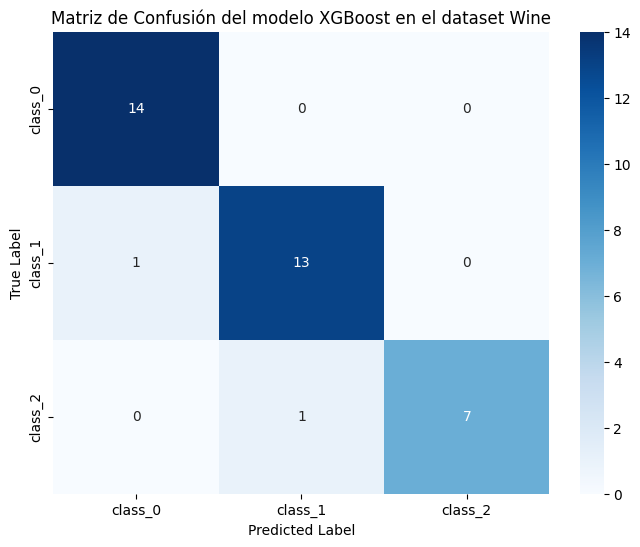

In [ ]:
# Creamos el modelo XGBoost con los mejores hiperparámetros encontrados
best_xgb_model_wine = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', learning_rate=0.01, n_estimators=50)

# Ajustamos el modelo XGBoost al conjunto de entrenamiento del dataset Wine discretizado
best_xgb_model_wine.fit(X_train_wine_discretizado, y_train_wine)

# Realizamos predicciones en el conjunto de validación del dataset Wine discretizado
y_pred_wine_xgb = best_xgb_model_wine.predict(X_valid_wine_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_wine_xgb = accuracy_score(y_valid_wine, y_pred_wine_xgb)
print("Validation accuracy del modelo XGBoost en el dataset Wine:", accuracy_wine_xgb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo XGBoost en el dataset Wine
precision_wine_xgb = precision_score(y_valid_wine, y_pred_wine_xgb, average='macro')
print("Precision del modelo XGBoost en el dataset Wine:", precision_wine_xgb)

recall_wine_xgb = recall_score(y_valid_wine, y_pred_wine_xgb, average='macro')
print("Recall del modelo XGBoost en el dataset Wine:", recall_wine_xgb)

f1_wine_xgb = f1_score(y_valid_wine, y_pred_wine_xgb, average='macro')
print("F1-Score del modelo XGBoost en el dataset Wine:", f1_wine_xgb)

# Generamos y mostramos el reporte de clasificación del modelo XGBoost en el dataset Wine
class_report_wine_xgb = classification_report(y_valid_wine, y_pred_wine_xgb)
print("Reporte de Clasificación del modelo XGBoost en el dataset Wine:\n", class_report_wine_xgb)

# Generamos y mostramos la matriz de confusión del modelo XGBoost en el dataset Wine
plot_confusion_matrix(y_valid_wine, y_pred_wine_xgb, class_names_wine, title='Matriz de Confusión del modelo XGBoost en el dataset Wine')

#### **4.4.4.3. Dataset Penguins**

In [ ]:
# Inicializamos el clasificador XGBoost
xgb_model_penguins = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
xgb_penguins_grid_search = GridSearchCV(estimator=xgb_model_penguins, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Penguins para encontrar los mejores parámetros
xgb_penguins_grid_search.fit(X_train_penguins_discretizado, y_train_penguins)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo XGBoost en el dataset Penguins
print("Mejores hiperparámetros para el modelo XGBoost en el dataset Penguins:", xgb_penguins_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para XGBoost en Penguins
print("Mejor validation accuracy para el modelo XGBoost en el dataset Penguins:", xgb_penguins_grid_search.best_score_)

Mejores hiperparámetros para el modelo XGBoost en el dataset Penguins: {'learning_rate': 0.01, 'n_estimators': 50}
Mejor validation accuracy para el modelo XGBoost en el dataset Penguins: 0.9774982529699511


Validation accuracy del modelo XGBoost en el dataset Penguins: 1.0
Precision del modelo XGBoost en el dataset Penguins: 1.0
Recall del modelo XGBoost en el dataset Penguins: 1.0
F1-Score del modelo XGBoost en el dataset Penguins: 1.0
Reporte de Clasificación del modelo XGBoost en el dataset Penguins:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



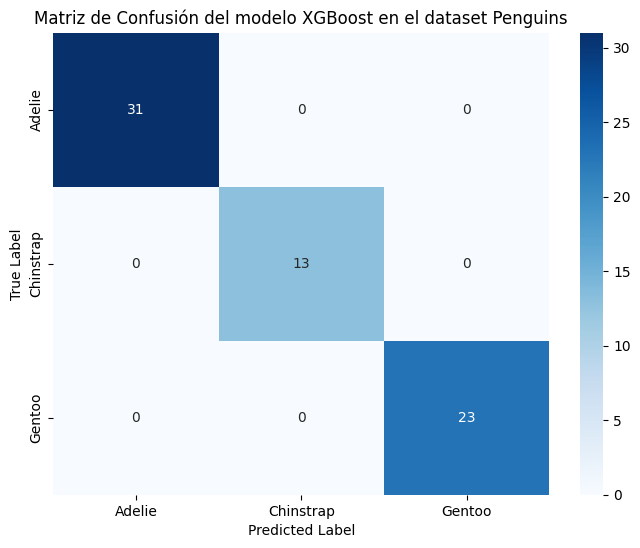

In [ ]:
# Creamos el modelo XGBoost con los mejores hiperparámetros encontrados
best_xgb_model_penguins = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', learning_rate=0.01, n_estimators=50)

# Ajustamos el modelo XGBoost al conjunto de entrenamiento del dataset Penguins discretizado
best_xgb_model_penguins.fit(X_train_penguins_discretizado, y_train_penguins)

# Realizamos predicciones en el conjunto de validación del dataset Penguins discretizado
y_pred_penguins_xgb = best_xgb_model_penguins.predict(X_valid_penguins_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_penguins_xgb = accuracy_score(y_valid_penguins, y_pred_penguins_xgb)
print("Validation accuracy del modelo XGBoost en el dataset Penguins:", accuracy_penguins_xgb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo XGBoost en el dataset Penguins
precision_penguins_xgb = precision_score(y_valid_penguins, y_pred_penguins_xgb, average='macro')
print("Precision del modelo XGBoost en el dataset Penguins:", precision_penguins_xgb)

recall_penguins_xgb = recall_score(y_valid_penguins, y_pred_penguins_xgb, average='macro')
print("Recall del modelo XGBoost en el dataset Penguins:", recall_penguins_xgb)

f1_penguins_xgb = f1_score(y_valid_penguins, y_pred_penguins_xgb, average='macro')
print("F1-Score del modelo XGBoost en el dataset Penguins:", f1_penguins_xgb)

# Generamos y mostramos el reporte de clasificación del modelo XGBoost en el dataset Penguins
class_report_penguins_xgb = classification_report(y_valid_penguins, y_pred_penguins_xgb)
print("Reporte de Clasificación del modelo XGBoost en el dataset Penguins:\n", class_report_penguins_xgb)

# Generamos y mostramos la matriz de confusión del modelo XGBoost en el dataset Penguins
plot_confusion_matrix(y_valid_penguins, y_pred_penguins_xgb, class_names_penguins, title='Matriz de Confusión del modelo XGBoost en el dataset Penguins')

#### **4.4.4.4. Dataset Tips**

In [ ]:
# Inicializamos el clasificador XGBoost
xgb_model_tips = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Configuramos GridSearchCV con el clasificador, la cuadrícula de parámetros, 5 pliegues de validación cruzada,
# ejecución paralela de trabajos y salida detallada durante el entrenamiento
xgb_tips_grid_search = GridSearchCV(estimator=xgb_model_tips, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)

# Ajustamos GridSearchCV a los datos de entrenamiento discretizados del dataset Tips para encontrar los mejores parámetros
xgb_tips_grid_search.fit(X_train_tips_discretizado, y_train_tips)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# Imprimimos los mejores hiperparámetros encontrados para el modelo XGBoost en el dataset Tips
print("Mejores hiperparámetros para el modelo XGBoost en el dataset Tips:", xgb_tips_grid_search.best_params_)

# Imprimimos el mejor puntaje de accuracy obtenido en la validación cruzada para XGBoost en Tips
print("Mejor validation accuracy para el modelo XGBoost en el dataset Tips:", xgb_tips_grid_search.best_score_)

Mejores hiperparámetros para el modelo XGBoost en el dataset Tips: {'learning_rate': 0.01, 'n_estimators': 50}
Mejor validation accuracy para el modelo XGBoost en el dataset Tips: 0.9589743589743589


Validation accuracy del modelo XGBoost en el dataset Tips: 1.0
Precision del modelo XGBoost en el dataset Tips: 1.0
Recall del modelo XGBoost en el dataset Tips: 1.0
F1-Score del modelo XGBoost en el dataset Tips: 1.0
Reporte de Clasificación del modelo XGBoost en el dataset Tips:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        15

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



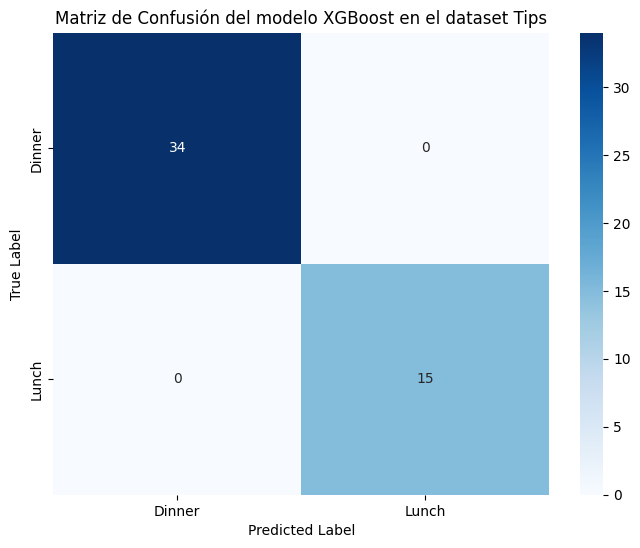

In [ ]:
# Creamos el modelo XGBoost con los mejores hiperparámetros encontrados
best_xgb_model_tips = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', learning_rate=0.01, n_estimators=50)

# Ajustamos el modelo XGBoost al conjunto de entrenamiento del dataset Tips discretizado
best_xgb_model_tips.fit(X_train_tips_discretizado, y_train_tips)

# Realizamos predicciones en el conjunto de validación del dataset Tips discretizado
y_pred_tips_xgb = best_xgb_model_tips.predict(X_valid_tips_discretizado)

# Calculamos y mostramos el accuracy de las predicciones comparándolas con las etiquetas reales del conjunto de validación
accuracy_tips_xgb = accuracy_score(y_valid_tips, y_pred_tips_xgb)
print("Validation accuracy del modelo XGBoost en el dataset Tips:", accuracy_tips_xgb)

# Calculamos y mostramos la precisión, sensibilidad y el F1-score del modelo XGBoost en el dataset Tips
precision_tips_xgb = precision_score(y_valid_tips, y_pred_tips_xgb, average='macro')
print("Precision del modelo XGBoost en el dataset Tips:", precision_tips_xgb)

recall_tips_xgb = recall_score(y_valid_tips, y_pred_tips_xgb, average='macro')
print("Recall del modelo XGBoost en el dataset Tips:", recall_tips_xgb)

f1_tips_xgb = f1_score(y_valid_tips, y_pred_tips_xgb, average='macro')
print("F1-Score del modelo XGBoost en el dataset Tips:", f1_tips_xgb)

# Generamos y mostramos el reporte de clasificación del modelo XGBoost en el dataset Tips
class_report_tips_xgb = classification_report(y_valid_tips, y_pred_tips_xgb)
print("Reporte de Clasificación del modelo XGBoost en el dataset Tips:\n", class_report_tips_xgb)

# Generamos y mostramos la matriz de confusión del modelo XGBoost en el dataset Tips
plot_confusion_matrix(y_valid_tips, y_pred_tips_xgb, class_names_tips, title='Matriz de Confusión del modelo XGBoost en el dataset Tips')

## **4.5. Recopilación de Resultados**

Las siguientes tablas muestran cómo cada algoritmo se desempeña en las distintas métricas para cada dataset, permitiendo así comparar fácilmente los resultados entre diferentes modelos y conjuntos de datos.

- **Dataset Iris:**

|    Métrica / Modelo    |  LBR  | Random Forest | Naive Bayes | k-NN | XGBoost |
|:------------------------:|:-------:|:---------------:|:-------------:|:------:|:---------:|
| **Validation Accuracy**| 0.967 |     0.933     | 0.967  | 0.833 | 0.967    |
| **Precision**          | 0.972 |     0.949     | 0.972  | 0.896 | 0.972    |
| **Recall**             | 0.963 |     0.926     | 0.963  | 0.815 | 0.963    |
| **F1-Score**           | 0.966 |     0.931     | 0.966  | 0.810 | 0.966    |


- **Dataset Wine:**

|    Métrica / Modelo    |  LBR  | Random Forest | Naive Bayes | k-NN | XGBoost |
|:------------------------:|:-------:|:---------------:|:-------------:|:------:|:---------:|
| **Validation Accuracy**| 0.972 | 1.000  | 1.000  | 0.944 | 0.944    |
| **Precision**          | 0.978 | 1.000  | 1.000  | 0.941 | 0.954    |
| **Recall**             | 0.976 | 1.000  | 1.000  | 0.952 | 0.935    |
| **F1-Score**           | 0.976 | 1.000  | 1.000  | 0.943 | 0.942    |


- **Dataset Penguins:**

|    Métrica / Modelo    |  LBR  | Random Forest | Naive Bayes | k-NN | XGBoost |
|:------------------------:|:-------:|:---------------:|:-------------:|:------:|:---------:|
| **Validation Accuracy**| 0.985 | 0.985  | 0.851  | 1.000 | 1.000    |
| **Precision**          | 0.976 | 0.976  | 0.845  | 1.000 | 1.000    |
| **Recall**             |0.989 | 0.989  | 0.892  | 1.000 | 1.000    |
| **F1-Score**           | 0.982 | 0.982  | 0.845  | 1.000 | 1.000    |


- **Dataset Tips:**

|    Métrica / Modelo    |  LBR  | Random Forest | Naive Bayes | k-NN | XGBoost |
|:------------------------:|:-------:|:---------------:|:-------------:|:------:|:---------:|
| **Validation Accuracy**| 0.980 | 0.980  | 0.959  | 0.959 | 1.000    |
| **Precision**          | 0.969 | 0.969  | 0.941  | 0.941 | 1.000    |
| **Recall**             |0.985 | 0.985  | 0.971  | 0.971 | 1.000    |
| **F1-Score**           | 0.976 | 0.976  | 0.954  | 0.954 | 1.000    |



Las siguientes gráficas ofrecen una visualización comprensiva del rendimiento de cada modelo evaluado, destacando las cuatro métricas clave: "Validation Accuracy", "Precision", "Recall" y "F1-Score". Estas representaciones gráficas facilitan la comparación inmediata entre los modelos en los distintos conjuntos de datos, permitiendo identificar visualmente en qué métricas y condiciones enfrenta desafíos cada modelo. Observar estas tendencias gráficamente ayuda a apreciar diferencias sutiles y patrones de rendimiento que podrían ser menos perceptibles a través de una tabla de resultados.

![](https://drive.google.com/uc?id=184P3KjGr_4MrhwCA6OsZ2DN_I54gT4gG)

![](https://drive.google.com/uc?id=1Z-_jyrMzhjcuJv8lAl9XqM6Wf0vz48bX)

![](https://drive.google.com/uc?id=1wWhEPBUtT47TYIg3f2Cpg4Gakjebp1M_)

![](https://drive.google.com/uc?id=1NnoiMIZj4aEW9w2J022YL8Si0iprqih8)

# **5. Discusión**

## **5.1. Interpretación de los Resultados**

La evaluación de los resultados obtenidos tras comparar el algoritmo de Reglas Bayesianas Perezosas (LBR) con otros clasificadores consolidados como Random Forest, Naive Bayes, k-NN, y XGBoost en los conjuntos de datos Iris, Wine, Penguins, y Tips revela una capacidad notable de LBR para adaptarse y funcionar de manera competitiva en diferentes escenarios de clasificación.

- **Eficacia de LBR:** Los resultados evidencian que LBR no sólo rivaliza efectivamente con métodos tradicionales, sino que en muchos casos los supera en términos de precisión. Por ejemplo, en el conjunto de datos Iris, LBR alcanzó una exactitud de validación y F1-Score de 0.967 y 0.966 respectivamente, cifras que son comparables o superiores a las de modelos bien establecidos como XGBoost y Random Forest, que presentaron valores similares de exactitud y F1-Score, pero con ligeras variaciones en otras métricas como precisión y recall.

- **Comparación con Modelos Clásicos:**

   - **Random Forest:** Mientras Random Forest logró una precisión perfecta en el conjunto de datos Wine con un F1-Score de 1.000, en otros conjuntos como Iris y Penguins, LBR mostró una robustez comparable, destacando su flexibilidad y su menor susceptibilidad al sobreajuste, con un F1-Score de 0.976 en Wine y 0.982 en Penguins.

   - **Naive Bayes:** Conocido por su eficacia en conjuntos de datos con alta dimensionalidad, Naive Bayes fue superado por LBR en el conjunto de datos Penguins, donde las interacciones complejas entre atributos juegan un rol crucial. LBR alcanzó una precisión de 0.976 y un recall de 0.989 frente a 0.845 y 0.892 de Naive Bayes, demostrando así la capacidad de LBR para manejar dependencias complejas entre atributos más eficazmente.

   - **k-NN y XGBoost:** LBR mantuvo una competitividad notable frente a k-NN y XGBoost, especialmente en el manejo de datos con atributos interdependientes. A pesar de que k-NN y XGBoost alcanzaron una exactitud de validación perfecta de 1.000 en Penguins, LBR demostró una capacidad similar en precisión y manejo de variabilidad entre los datos, lo que subraya la eficacia de la estrategia de aprendizaje perezoso frente a métodos basados en instancias y técnicas de ensamblaje avanzadas.

## **5.2. Ventajas y Limitaciones**

- **Ventajas de LBR:**

   - La implementación del algoritmo de Reglas Bayesianas Perezosas (LBR) ha mostrado varias ventajas significativas en su aplicación a diversos conjuntos de datos. Una de las principales fortalezas de LBR es su capacidad de generar reglas específicas para cada instancia, lo que permite un ajuste muy fino a las características particulares de cada ejemplo. Esto resulta en una alta precisión de clasificación, especialmente en conjuntos de datos con dimensiones y relaciones complejas entre atributos. Por ejemplo, en los conjuntos de datos de Iris y Wine, LBR ha demostrado ser competitivo con modelos estadísticos consolidados, alcanzando niveles de precisión y exactitud que rivalizan o superan a métodos como Random Forest y Naive Bayes.

   - Además, LBR es particularmente efectivo en datasets con un número moderado de instancias, donde cada ejemplo puede ser considerado de manera más individualizada sin un coste computacional prohibitivo. Esto se refleja en su rendimiento en los datasets de Penguins y Tips, donde la capacidad de adaptar las reglas de clasificación a las particularidades de cada instancia facilita una clasificación más precisa y ajustada a las necesidades del análisis.

- **Limitaciones de LBR:**

   - Sin embargo, a pesar de estas ventajas, LBR no está exento de limitaciones. Una de las principales desventajas es su eficiencia computacional en conjuntos de datos de gran tamaño. Debido a su enfoque de aprendizaje perezoso, que implica la generación de reglas específicas para cada instancia en el momento de la clasificación, LBR puede requerir un tiempo de computación significativamente más alto comparado con algoritmos más simplificados que no recalculan las decisiones para cada nueva instancia. En contextos donde el volumen de datos es extenso o donde se requiere una respuesta en tiempo real, esto podría ser impracticable sin el uso de optimizaciones o hardware especializado.

   - Además, aunque LBR maneja bien las interdependencias entre atributos, su necesidad de mantener todas las instancias de entrenamiento disponibles durante la clasificación aumenta los requisitos de memoria, lo que puede ser un desafío en aplicaciones con recursos limitados o cuando se trabaja con conjuntos de datos extremadamente grandes.

En resumen, mientras que LBR ofrece un enfoque altamente adaptativo y preciso para la clasificación en conjuntos de datos con complejidades inter-atributos y un número moderado de instancias, su aplicabilidad puede estar limitada por consideraciones de eficiencia computacional y escalabilidad en escenarios de big data. Estos aspectos subrayan la necesidad de considerar cuidadosamente el contexto de uso al elegir LBR como herramienta de clasificación.

# **6. Conclusiones y Trabajos Futuros**

## **6.1. Conclusiones Principales**

Este proyecto ha explorado la implementación y eficacia del algoritmo de Reglas Bayesianas Perezosas (LBR), introduciendo una metodología innovadora en el ámbito de la clasificación que se distingue por su capacidad para adaptarse a las especificidades de cada instancia. A través de la evaluación comparativa con otros modelos clásicos como Random Forest, Naive Bayes, k-NN y XGBoost, LBR ha demostrado ser una técnica competitiva y efectiva, particularmente en contextos donde la interdependencia entre atributos y la precisión en la clasificación son críticas.

Uno de los hallazgos más destacados de este estudio es la capacidad de LBR para manejar dependencias de atributos de manera más efectiva que el clasificador Naive Bayes estándar, al minimizar los problemas asociados con la suposición de independencia de los atributos. La utilización de reglas bayesianas generadas dinámicamente permite a LBR evitar el problema de los "pequeños disjuntos" y adaptar los clasificadores locales de manera más precisa a las instancias específicas. Además, los resultados experimentales han validado que LBR puede superar o igualar el rendimiento de técnicas consolidadas en una variedad de dominios naturales, manteniendo o mejorando la precisión de la clasificación incluso en conjuntos de datos complejos.

Sin embargo, LBR también presenta limitaciones, especialmente en su aplicabilidad a conjuntos de datos muy grandes debido a su intensiva demanda computacional. Aunque ofrece una precisión de clasificación mejorada en conjuntos de datos con un número moderado de instancias, la escalabilidad sigue siendo un desafío cuando se enfrenta a grandes volúmenes de datos.

## **6.2. Potenciales Mejoras y Líneas de Investigación Futuras**

A pesar de los resultados prometedores obtenidos con el algoritmo de Reglas Bayesianas Perezosas (LBR), existen varias áreas de mejora que podrían explorarse para potenciar aún más su aplicabilidad y eficacia. Estas áreas no solo buscan optimizar el rendimiento del algoritmo en términos de precisión y eficiencia, sino también expandir su utilidad en un espectro más amplio de aplicaciones. A continuación, se detallan algunas de las mejoras y líneas de investigación futuras que podrían contribuir significativamente al desarrollo de LBR:

   - **Optimización y Escalabilidad:** Desarrollar métodos para mejorar la eficiencia computacional de LBR, posiblemente mediante técnicas de paralelización o algoritmos más eficientes para la gestión de la memoria. Esto podría ampliar la aplicabilidad de LBR a conjuntos de datos más grandes y a entornos en tiempo real, abriendo la puerta a aplicaciones que requieren respuestas rápidas como el procesamiento de transacciones o análisis en tiempo real.

   - **Extensión a Atributos Numéricos:** Explorar métodos integrados para manejar atributos numéricos directamente dentro de LBR sin necesidad de discretización previa, lo que podría mejorar la precisión de las reglas generadas y simplificar el proceso de preparación de datos. Esto permitiría a LBR manejar de manera más efectiva y precisa una variedad de tipos de datos en diversos contextos.

   - **Aplicaciones en Nuevos Dominios:** Aplicar LBR en otros campos como la bioinformática, la detección de fraudes o la personalización de contenidos, donde las interacciones complejas entre atributos son comunes y la precisión de clasificación es crucial. La capacidad de LBR para adaptarse a las especificidades de cada caso podría ser particularmente valiosa en estas áreas.

   - **Integración con Técnicas de Aprendizaje Profundo:** Investigar la combinación de LBR con modelos de aprendizaje profundo para explorar cómo la generación de reglas bayesianas podría complementarse con representaciones de características aprendidas de manera profunda. Esto podría resultar en una mejora sustancial del rendimiento en tareas que requieren un alto grado de abstracción y representación de datos complejos, como el procesamiento de lenguaje natural o la visión por computadora.

   - **Mejora en el Manejo de Datos Faltantes y Ruidosos:** Optimizar aún más la estrategia de LBR para manejar valores faltantes y datos ruidosos, posiblemente mediante técnicas avanzadas de imputación o métodos robustos para el manejo de outliers. Esto aumentaría la robustez de LBR frente a la calidad variable de los datos.

   - **Desarrollo de Frameworks de Evaluación Más Rigurosos:** Para validar de manera más efectiva las mejoras en LBR y su comparación con otras técnicas, es crucial desarrollar frameworks de evaluación que consideren no solo la precisión de clasificación sino también factores como la interpretabilidad de las reglas generadas, el tiempo de ejecución y el consumo de recursos.


Estas áreas de investigación no solo están destinadas a perfeccionar la técnica de LBR, sino que también pretenden explorar cómo las estrategias de aprendizaje perezoso pueden ser adaptadas y aplicadas de manera más general para resolver problemas complejos en el campo del aprendizaje automático, proporcionando soluciones más flexibles, precisas y eficientes.

# **7. Bibliografía**

[1] Zheng, Z., & Webb, G. I. (2000). Lazy learning of Bayesian rules. Machine Learning, 41(1), 53-84.

[2] Langley, P., & Sage, S. (1994). Induction of selective Bayesian classifiers. Proceedings of the Tenth Conference on Uncertainty in Artificial Intelligence, 399-406.

[3] Kohavi, R., & John, G. H. (1997). Wrappers for feature subset selection. Artificial Intelligence, 97(1-2), 273-324.

[4] Friedman, N., Geiger, D., & Goldszmidt, M. (1997). Bayesian network classifiers. Machine Learning, 29(2-3), 131-163.

[5] Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss. Machine Learning, 29(2-3), 103-130.

[6] Langley, P. (1994). Selection of relevant features in machine learning. In Proceedings of the AAAI Fall Symposium on Relevance, 140-144.

[7] Mitchell, T. M. (1997). Machine Learning. McGraw-Hill, Inc.

[8] Webb, G. I., Boughton, J., & Wang, Z. (2005). Not so naive Bayes: Aggregating one-dependence estimators. Machine Learning, 58(1), 5-24.

[9] Witten, I. H., Frank, E., Hall, M. A., & Pal, C. J. (2016). Data Mining: Practical Machine Learning Tools and Techniques (Fourth Edition). Morgan Kaufmann.

[10] Aha, D. W., Kibler, D., & Albert, M. K. (1991). Instance-based learning algorithms. Machine Learning, 6, 37–66.

[11] Aha, D. W. (Ed.) (1997). Lazy learning. Dordrecht: Kluwer Academic.

[12] Blake, C., Keogh, E., & Merz, C. J. (1998). UCI repository of machine learning databases. Department of Information and Computer Science, University of California, Irvine, CA.

[13] Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). Classification and regression trees. Belmont, CA: Wadsworth.

[14] Chow, C. K. & Liu, C. N. (1968). Approximating discrete probability distributions with dependence trees. IEEE Transactions on Information Theory, 14, 462–467.

[15] Domingos, P. & Pazzani, M. (1996). Beyond independence: Conditions for the optimality of the simple Bayesian classifier. In Proceedings of the Thirteenth International Conference on Machine Learning, 105-112. San Francisco, CA: Morgan Kaufmann.

[16] Friedman, N. & Goldszmidt, M. (1996). Building classifiers using Bayesian networks. In Proceedings of the Thirteenth National Conference on Artificial Intelligence, 1277–1284. Menlo Park, CA: The AAAI Press.

[17] Holte, R. C., Acker, L. E., & Porter, B. W. (1989). Concept learning and the problem of small disjuncts. In Proceedings of the Eleventh International Joint Conference on Artificial Intelligence, 813-818. San Mateo, CA: Morgan Kaufmann.

[18] John, G. H., Kohavi, R., & Pfleger, K. (1994). Irrelevant features and the subset selection problem. In Proceedings of the Eleventh International Conference on Machine Learning, 121-129. San Francisco, CA: Morgan Kaufmann.

[19] Quinlan, J. R. (1993). C4.5: Programs for machine learning. San Mateo, CA: Morgan Kaufmann.

[20] Kohavi, R. (1996). Scaling up the accuracy of naive-Bayes classifiers: A decision-tree hybrid. In Proceedings of the Second International Conference on Knowledge Discovery and Data Mining, 202-207. Menlo Park, CA: The AAAI Press.